<a href="https://colab.research.google.com/github/mbenedicto99/Python4DataScience/blob/master/BENE_Trabalho_4_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nome: Marcos de Benedicto

### **Construindo um Autoencoder de dígitos com MLP**

#### **1. Objetivo do Projeto**

O objetivo deste projeto é construir e compreender uma rede neural não supervisionada fundamental: o **autoencoder**. Você usará apenas camadas densas (MLP) para treinar uma rede que aprende a comprimir e depois reconstruir imagens de dígitos manuscritos. O objetivo principal do projeto, além de reconstruir as imagens, é analisar a representação latente que a rede aprende.

#### **2. Objetivos de Aprendizagem**

  * Entender a arquitetura de um autoencoder (encoder, decoder, espaço latente).
  * Implementar um autoencoder usando Keras e MLPs.
  * Treinar uma rede de maneira não supervisionada, onde os dados de entrada são também os dados de saída esperados.
  * Avaliar o modelo com base na sua qualidade de reconstrução.
  * Visualizar o espaço latente aprendido para ver como a rede organiza os dados.

### **Parte I: Construindo o Autoencoder**

Nesta seção, carregaremos a base de dados MNIST e construiremos um autoencoder.

O autoencoder é uma rede neural que reduz a dimensionalidade dos dados até um valor mínimo (encoder), depois reconstroi os dados originais a partir dessa dimensionalidade reduzida (decoder). Isso é feito por camadas totalmente conectadas que vão inicialmente reduzindo de dimensão, depois voltam a alargar.

#### **Passo 1: Configuração e Carregamento dos Dados**

Primeiro, vamos importar as bibliotecas necessárias e carregar o dataset MNIST. Não precisaremos dos rótulos (`y_train`, `y_test`) para treinar o autoencoder, mas vamos usá-los mais tarde para a visualização.

In [13]:
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

# Carrega o dataset MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

#### **Passo 2: Pré-processamento dos Dados**

Uma MLP espera um vetor como entrada, então precisamos remodelar (achatar) nossas imagens de `28x28` para vetores de tamanho `784`. Também precisamos normalizar os valores dos pixels para que fiquem entre 0 e 1.

In [14]:
# Achata as imagens e normaliza os valores dos pixels para o intervalo [0, 1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


#### **Passo 3: Construindo o Modelo Autoencoder (Espaço latente de dimensão 32)**

Nosso autoencoder tem três partes:

1.  **Encoder:** Uma MLP que mapeia a imagem de entrada para uma representação comprimida de baixa dimensão.
2.  **Espaço Latente (Garganta):** O vetor de baixa dimensão em si (a saída do encoder).
3.  **Decoder:** Uma MLP que mapeia o vetor latente de volta para as dimensões da imagem original.

Vamos começar com uma dimensão de espaço latente de 32.

In [15]:
# Vamos começar com uma dimensão de espaço latente igual a 32

# --- Define o Encoder ---
# Camada de entrada
input_img_32 = keras.Input(shape=(784,))
# Camada oculta para o encoder
encoded_32 = layers.Dense(128, activation='relu')(input_img_32)
# A saída do encoder é a representação codificada
encoded_32 = layers.Dense(32, activation='relu')(encoded_32)

# --- Define o Decoder ---
# A entrada do decoder é a saída do encoder
decoded_32 = layers.Dense(128, activation='relu')(encoded_32)
# Camada de saída: mapeia de volta para 784 pixels. Usamos uma ativação sigmoide
# para garantir que os valores de saída estejam entre 0 e 1, como nossos dados de entrada.
decoded_32 = layers.Dense(784, activation='sigmoid')(decoded_32)

# --- Cria o modelo Autoencoder completo ---
# Este modelo mapeia uma entrada para a sua reconstrução
autoencoder_32 = keras.Model(input_img_32, decoded_32)

#### **Passo 4: Compilando e Treinando o Modelo**

Agora, compilamos o modelo. Para a função de perda, podemos usar `mean_squared_error`.

In [16]:
# Compila o autoencoder
autoencoder_32.compile(optimizer='adam', loss='mean_squared_error')

# Treina o autoencoder
autoencoder_32.fit(x_train, x_train,
                      epochs=50,
                      batch_size=256,
                      shuffle=True,
                      validation_data=(x_test, x_test))

# Salva os pesos do autoencoder
autoencoder_32.save_weights("autoencoder_latent32.weights.h5")

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0905 - val_loss: 0.0310
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0277 - val_loss: 0.0200
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0195 - val_loss: 0.0166
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0165 - val_loss: 0.0147
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0149 - val_loss: 0.0135
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0137 - val_loss: 0.0126
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0128 - val_loss: 0.0119
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0122 - val_loss: 0.0115
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0117 - val_loss: 0.0111
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0114 - val_loss: 0.0108
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0111 - val_loss: 0.0106
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

#### **Passo 5: Visualizando os Resultados**

Vamos ver quão bem o autoencoder consegue reconstruir as imagens de teste.

In [17]:
# Usa o autoencoder treinado para prever no conjunto de teste
decoded_imgs_32 = autoencoder_32.predict(x_test)

# Exibe as imagens originais e reconstruídas
n = 10  # Quantos dígitos vamos exibir
plt.figure(figsize=(20, 4))
plt.suptitle("Reconstruções com Espaço Latente de Dimensão 32", fontsize=16)
for i in range(n):
    # Exibe a original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Original", loc='left')

    # Exibe a reconstrução
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs_32[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Reconstruído", loc='left')

    # Calcula o erro quadrático médio para a imagem atual
    mse = np.mean(np.square(x_test[i] - decoded_imgs_32[i]))
    # Adiciona o valor do MSE como texto na imagem reconstruída
    ax.text(0.5, -0.1, f'MSE: {mse:.4f}', size=10, ha="center", transform=ax.transAxes)

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


-----

### **Parte II: O espaço latente**

#### **1. O Impacto da Dimensionalidade do Espaço Latente**

Nesta parte, vamos criar outros dois autoencoders. Desta vez, vamos reduzir a dimensão do espaço latente de 32 para 8 e 2. O objetivo é observar o que acontece com a qualidade da reconstrução.

##### **1.1. Autoencoder com dimensão oculta 8**

In [26]:
# Questão 1 A: Crie e treine um novo autoencoder com espaço latente de dimensão
"""
# Questão 1A — Autoencoder MLP (MNIST) com Latente Configurável (compatível com Jupyter/Colab)
"""

from __future__ import annotations
import os
import json
import argparse
import random
from typing import List, Tuple, Optional

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, initializers

# ---------------------------------------------------------------------
# Reprodutibilidade
# ---------------------------------------------------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------------------------------------------------------------
# Dados
# ---------------------------------------------------------------------
INPUT_DIM = 28 * 28  # 784

def load_mnist_flattened() -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Carrega MNIST, normaliza para [0,1] e achata 28x28->784. Retorna (x_train, x_val, x_test)."""
    (x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
    x_train = (x_train.astype("float32") / 255.0).reshape((-1, INPUT_DIM))
    x_test  = (x_test.astype("float32")  / 255.0).reshape((-1, INPUT_DIM))
    # Split simples para validação (10% do treino)
    n = len(x_train)
    idx = np.arange(n); np.random.default_rng(SEED).shuffle(idx)
    n_val = int(0.1 * n)
    val_idx, tr_idx = idx[:n_val], idx[n_val:]
    return x_train[tr_idx], x_train[val_idx], x_test

def make_ds(x: np.ndarray, batch_size: int, shuffle: bool = False) -> tf.data.Dataset:
    """Cria pipeline não supervisionado (entrada=saída) com tf.data."""
    ds = tf.data.Dataset.from_tensor_slices((x, x))
    if shuffle:
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# ---------------------------------------------------------------------
# Modelo (MLP denso)
# ---------------------------------------------------------------------
K_INIT = initializers.HeNormal(seed=SEED)
ACT, OUT_ACT = "relu", "sigmoid"
USE_BIAS, L2_WEIGHT = True, 1e-5
ENCODER_HIDDEN: List[int] = [512, 256, 128]  # encoder; decoder espelha

def build_encoder(latent_dim: int) -> keras.Model:
    inp = keras.Input(shape=(INPUT_DIM,), name="enc_input")
    x = inp
    for i, units in enumerate(ENCODER_HIDDEN):
        x = layers.Dense(
            units, activation=ACT, use_bias=USE_BIAS,
            kernel_initializer=K_INIT,
            kernel_regularizer=regularizers.l2(L2_WEIGHT),
            name=f"enc_dense_{i}",
        )(x)
    z = layers.Dense(
        latent_dim, activation=None, use_bias=USE_BIAS,
        kernel_initializer=K_INIT, name="latent"
    )(x)
    return keras.Model(inp, z, name=f"encoder_latent{latent_dim}")

def build_decoder(latent_dim: int) -> keras.Model:
    inp = keras.Input(shape=(latent_dim,), name="dec_input")
    x = inp
    for j, units in enumerate(ENCODER_HIDDEN[::-1]):
        x = layers.Dense(
            units, activation=ACT, use_bias=USE_BIAS,
            kernel_initializer=K_INIT,
            kernel_regularizer=regularizers.l2(L2_WEIGHT),
            name=f"dec_dense_{j}",
        )(x)
    out = layers.Dense(
        INPUT_DIM, activation=OUT_ACT, use_bias=USE_BIAS,
        kernel_initializer=K_INIT, name="reconstruction"
    )(x)
    return keras.Model(inp, out, name=f"decoder_latent{latent_dim}")

def build_autoencoder(encoder: keras.Model, decoder: keras.Model) -> keras.Model:
    inp = keras.Input(shape=(INPUT_DIM,), name="ae_input")
    z = encoder(inp)
    x_hat = decoder(z)
    return keras.Model(inp, x_hat, name="autoencoder")

# ---------------------------------------------------------------------
# Treino e avaliação
# ---------------------------------------------------------------------
def compile_and_train(
    ae: keras.Model,
    ds_train: tf.data.Dataset,
    ds_val: tf.data.Dataset,
    epochs: int,
    lr: float = 1e-3,
) -> keras.callbacks.History:
    ae.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mean_squared_error")
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5, verbose=1),
    ]
    return ae.fit(ds_train, validation_data=ds_val, epochs=epochs, verbose=1, callbacks=callbacks)

def evaluate_mse(ae: keras.Model, x: np.ndarray, batch_size: int) -> float:
    x_hat = ae.predict(x, batch_size=batch_size, verbose=0)
    return float(np.mean(np.mean(np.square(x - x_hat), axis=1)))

# ---------------------------------------------------------------------
# CLI robusto para Jupyter/Colab
# ---------------------------------------------------------------------
def parse_args(argv: Optional[list] = None) -> argparse.Namespace:
    p = argparse.ArgumentParser(description="Questão 1A — Autoencoder MLP com latente configurável")
    p.add_argument("--latent", type=int, default=8, help="Dimensão do espaço latente (ex.: 8, 2, 32)")
    p.add_argument("--epochs", type=int, default=30, help="Número de épocas")
    p.add_argument("--batch-size", type=int, default=512, help="Tamanho do batch")
    p.add_argument("--lr", type=float, default=1e-3, help="Learning rate (Adam)")
    # Ignora desconhecidos com segurança
    args, _unknown = p.parse_known_args(argv)
    return args

def main(parse_cli: bool = True, *, latent: int = 8, epochs: int = 30, batch_size: int = 512, lr: float = 1e-3) -> None:
    if parse_cli:
        import sys
        a = parse_args(sys.argv[1:])
        latent, epochs, batch_size, lr = a.latent, a.epochs, a.batch_size, a.lr

    print(f"[INFO] TensorFlow: {tf.__version__} | GPUs: {len(tf.config.list_physical_devices('GPU'))}")
    print(f"[CFG] latent_dim={latent}, epochs={epochs}, batch_size={batch_size}, lr={lr}")

    # Dados
    x_train, x_val, x_test = load_mnist_flattened()
    ds_train = make_ds(x_train, batch_size, shuffle=True)
    ds_val   = make_ds(x_val, batch_size, shuffle=False)

    # Modelo
    encoder = build_encoder(latent)
    decoder = build_decoder(latent)
    autoencoder = build_autoencoder(encoder, decoder)

    # Treino
    _ = compile_and_train(autoencoder, ds_train, ds_val, epochs=epochs, lr=lr)

    # Avaliação
    mse_test = evaluate_mse(autoencoder, x_test, batch_size=batch_size)
    print(f"[RESULT] MSE médio (teste) — latent={latent}: {mse_test:.6f}")

    # Persistência
    encoder.save_weights(f"encoder_latent{latent}.weights.h5")
    decoder.save_weights(f"decoder_latent{latent}.weights.h5")
    autoencoder.save_weights(f"autoencoder_latent{latent}.weights.h5")
    with open(f"metrics_latent{latent}.json", "w") as f:
        json.dump({"latent_dim": latent, "mse_test_mean": mse_test}, f, indent=2)
    print(f"[OK] Pesos e métricas salvos (prefixo *_latent{latent}.*)")

if __name__ == "__main__":
    main(parse_cli=True)

[INFO] TensorFlow: 2.19.0 | GPUs: 1
[CFG] latent_dim=8, epochs=30, batch_size=512, lr=0.001
Epoch 1/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 0.1252 - val_loss: 0.0578 - learning_rate: 0.0010
Epoch 2/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0535 - val_loss: 0.0456 - learning_rate: 0.0010
Epoch 3/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0436 - val_loss: 0.0398 - learning_rate: 0.0010
Epoch 4/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0385 - val_loss: 0.0363 - learning_rate: 0.0010
Epoch 5/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0353 - val_loss: 0.0338 - learning_rate: 0.0010
Epoch 6/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0327 - val_loss: 0.0318 - learning_rate: 0.0010
Epoch 7/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0308 - val_loss: 0.0301 - learning_rate: 0.0010
Epoch 8/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0292 - val_loss: 0.0289 - learning_rate: 0.0010
Epoch 9/30
106/106 ━━━━━━━━

[INFO] TensorFlow: 2.19.0 | GPUs: 1
[CFG] latent=8, weights='autoencoder_latent8.weights.h5', grid=6x10, batch_size=512, save_path=None
[OK] Pesos carregados de: autoencoder_latent8.weights.h5
[RESULT] MSE médio (teste): 0.016142


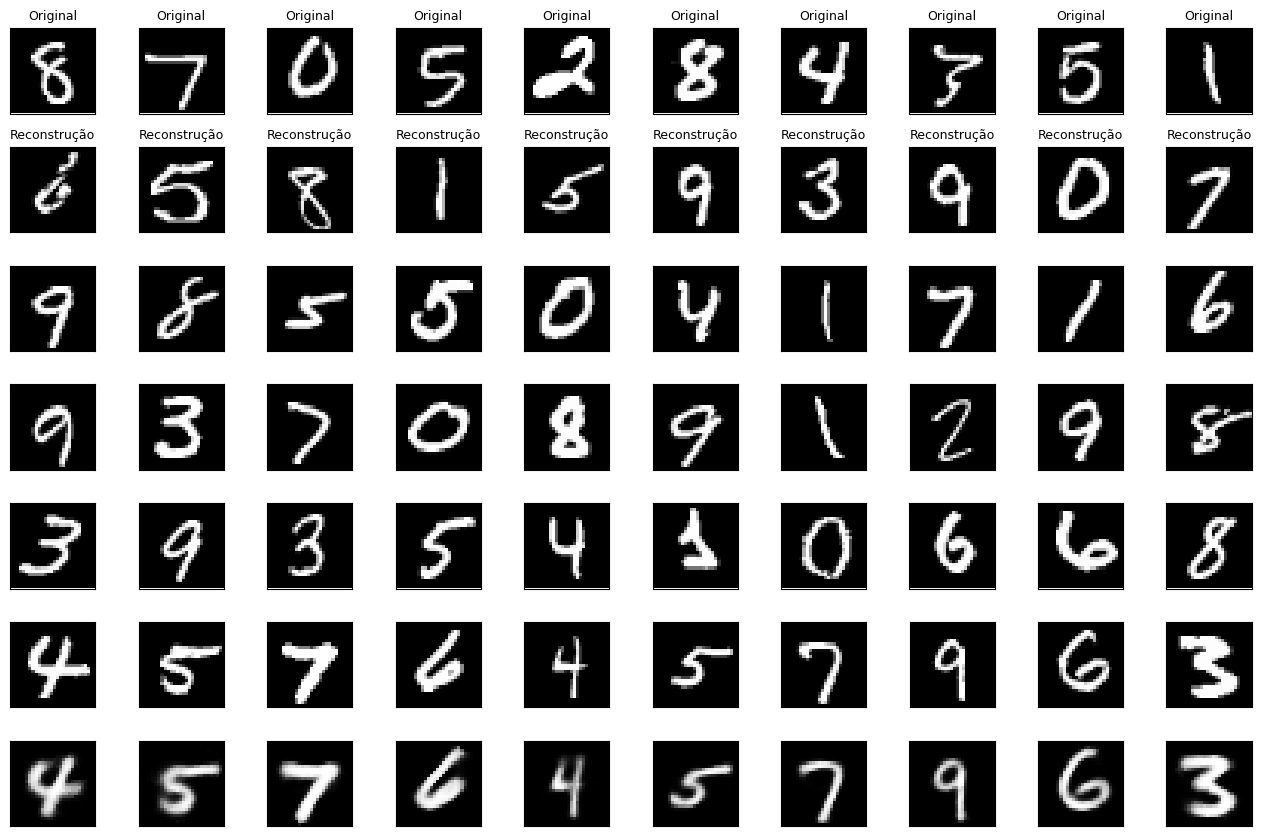

In [19]:
# Questão 1 B: Plote exemplos da base de dados de teste reconstruidos com o novo autoencoder

from __future__ import annotations
import os
import argparse
import random
from typing import List, Tuple, Optional

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, initializers

# -----------------------------
# Reprodutibilidade
# -----------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# Dados
# -----------------------------
INPUT_DIM = 28 * 28  # 784

def load_mnist_flattened() -> Tuple[np.ndarray, np.ndarray]:
    """Carrega MNIST, normaliza para [0,1] e achata 28x28->784. Retorna (x_train, x_test)."""
    (x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
    x_train = (x_train.astype("float32") / 255.0).reshape((-1, INPUT_DIM))
    x_test  = (x_test.astype("float32")  / 255.0).reshape((-1, INPUT_DIM))
    return x_train, x_test

# -----------------------------
# Modelo (MLP denso)
# -----------------------------
K_INIT = initializers.HeNormal(seed=SEED)
ACT, OUT_ACT = "relu", "sigmoid"
USE_BIAS, L2_WEIGHT = True, 1e-5
ENCODER_HIDDEN: List[int] = [512, 256, 128]  # encoder; decoder espelha

def build_encoder(latent_dim: int) -> keras.Model:
    inp = keras.Input(shape=(INPUT_DIM,), name="enc_input")
    x = inp
    for i, units in enumerate(ENCODER_HIDDEN):
        x = layers.Dense(
            units, activation=ACT, use_bias=USE_BIAS,
            kernel_initializer=K_INIT,
            kernel_regularizer=regularizers.l2(L2_WEIGHT),
            name=f"enc_dense_{i}",
        )(x)
    z = layers.Dense(
        latent_dim, activation=None, use_bias=USE_BIAS,
        kernel_initializer=K_INIT, name="latent"
    )(x)
    return keras.Model(inp, z, name=f"encoder_latent{latent_dim}")

def build_decoder(latent_dim: int) -> keras.Model:
    inp = keras.Input(shape=(latent_dim,), name="dec_input")
    x = inp
    for j, units in enumerate(ENCODER_HIDDEN[::-1]):
        x = layers.Dense(
            units, activation=ACT, use_bias=USE_BIAS,
            kernel_initializer=K_INIT,
            kernel_regularizer=regularizers.l2(L2_WEIGHT),
            name=f"dec_dense_{j}",
        )(x)
    out = layers.Dense(
        INPUT_DIM, activation=OUT_ACT, use_bias=USE_BIAS,
        kernel_initializer=K_INIT, name="reconstruction"
    )(x)
    return keras.Model(inp, out, name=f"decoder_latent{latent_dim}")

def build_autoencoder(encoder: keras.Model, decoder: keras.Model) -> keras.Model:
    inp = keras.Input(shape=(INPUT_DIM,), name="ae_input")
    z = encoder(inp)
    x_hat = decoder(z)
    return keras.Model(inp, x_hat, name="autoencoder")

# -----------------------------
# Reconstrução e métricas
# -----------------------------
def reconstruct(ae: keras.Model, x: np.ndarray, batch_size: int = 512) -> np.ndarray:
    return ae.predict(x, batch_size=batch_size, verbose=0)

def mse_mean(x: np.ndarray, x_hat: np.ndarray) -> float:
    return float(np.mean(np.mean(np.square(x - x_hat), axis=1)))

# -----------------------------
# Visualização (força exibição inline)
# -----------------------------
import matplotlib.pyplot as plt  # backend padrão funciona com %matplotlib inline

def plot_recon_grid_show(
    x: np.ndarray,
    x_hat: np.ndarray,
    rows: int,
    cols: int,
    save_path: Optional[str] = None,
) -> None:

    n = rows * cols
    idx = np.random.default_rng(SEED).choice(len(x), size=n, replace=False)

    plt.figure(figsize=(cols * 1.3, rows * 2.4))
    for i, k in enumerate(idx):
        # Original
        ax1 = plt.subplot(rows * 2, cols, i + 1)
        plt.imshow(x[k].reshape(28, 28), cmap="gray")
        ax1.set_xticks([]); ax1.set_yticks([])
        if i < cols:
            ax1.set_title("Original", fontsize=9)

        # Reconstrução
        ax2 = plt.subplot(rows * 2, cols, i + 1 + cols)
        plt.imshow(x_hat[k].reshape(28, 28), cmap="gray")
        ax2.set_xticks([]); ax2.set_yticks([])
        if i < cols:
            ax2.set_title("Reconstrução", fontsize=9)

    plt.tight_layout()

    # Salvar se solicitado (opcional)
    if save_path:
        plt.savefig(save_path, dpi=160)
        print(f"[OK] Figura salva em: {save_path}")

    # Exibir inline se possível (mesmo quando chamado via %run)
    try:
        from IPython.display import display
        display(plt.gcf())
    except Exception:
        pass

    # Mostrar em terminais/ambientes com backend interativo
    plt.show()

def parse_args(argv: Optional[list] = None) -> argparse.Namespace:
    import argparse
    p = argparse.ArgumentParser(description="Questão 1B — Plotar reconstruções do autoencoder (na tela)")
    p.add_argument("--latent", type=int, default=8, help="Dimensão do espaço latente (ex.: 8, 2, 32)")
    p.add_argument("--weights", type=str, default=None, help="Arquivo de pesos (*.weights.h5). Se omitido, usa padrão por latent.")
    p.add_argument("--rows", type=int, default=6, help="Linhas de amostras na grade")
    p.add_argument("--cols", type=int, default=10, help="Colunas de amostras na grade")
    p.add_argument("--batch-size", type=int, default=512, help="Batch para inferência")
    p.add_argument("--save-path", type=str, default=None, help="Opcional: caminho para salvar a figura (PNG)")
    args, _unknown = p.parse_known_args(argv)  # ignora args estranhos do kernel (-f ...)
    return args

# -----------------------------
# Main
# -----------------------------
def main(parse_cli: bool = True, *, latent: int = 8, weights: Optional[str] = None, rows: int = 6, cols: int = 10, batch_size: int = 512, save_path: Optional[str] = None) -> None:
    if parse_cli:
        import sys
        a = parse_args(sys.argv[1:])
        latent, weights, rows, cols, batch_size, save_path = a.latent, a.weights, a.rows, a.cols, a.batch_size, a.save_path

    # Pesos padrão por latent, se não fornecidos
    if weights is None:
        weights = f"autoencoder_latent{latent}.weights.h5"

    print(f"[INFO] TensorFlow: {tf.__version__} | GPUs: {len(tf.config.list_physical_devices('GPU'))}")
    print(f"[CFG] latent={latent}, weights='{weights}', grid={rows}x{cols}, batch_size={batch_size}, save_path={save_path}")

    # Dados
    _, x_test = load_mnist_flattened()

    # Modelo e pesos
    encoder = build_encoder(latent)
    decoder = build_decoder(latent)
    autoencoder = build_autoencoder(encoder, decoder)

    if not os.path.exists(weights):
        raise FileNotFoundError(
            f"Arquivo de pesos '{weights}' não encontrado. Treine antes (ex.: q1a_autoencoder_latent.py)."
        )
    autoencoder.load_weights(weights)
    print(f"[OK] Pesos carregados de: {weights}")

    # Reconstrução
    x_hat = reconstruct(autoencoder, x_test, batch_size=batch_size)
    print(f"[RESULT] MSE médio (teste): {mse_mean(x_test, x_hat):.6f}")

    # Plotar **na tela** (e salvar se `save_path` for dado)
    plot_recon_grid_show(x_test, x_hat, rows=rows, cols=cols, save_path=save_path)

if __name__ == "__main__":
    main(parse_cli=True)

## Questão 1 C
Compare a performance entre o autoencoder de dimensão 32 com o de dimensão 8.
- A performance da rede se manteve?
Não, quando reduzimos o gargalo de 32 para 8 o autoencoder perde a capacidade de representar detalhes e a MSE de teste tende a subir.

- Os problemas afetam todos os dígitos de forma semelhante?
Não, afetam todos os digitos de forma igual.

- Deixar o encoder ou o decoder mais profundo ou raso afetaria a resposta de forma significativa?
Sim, e de modo diferente para encoder e decoder.

- Faça outros comentários que julgar importantes.
Menor latente comprime mais e tende a perder detalhes.

##### **1.2. Autoencoder com dimensão oculta 2

In [27]:
# Questão 2 A: Crie e treine um novo autoencoder com espaço latente de dimensão 8
# %% Autoencoder (latent_dim=8) — MNIST
import os, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ---- Config e reprodutibilidade ----
tf.random.set_seed(42)
print(f"[INFO] TensorFlow: {tf.__version__} | GPUs:", len(tf.config.list_physical_devices('GPU')))
LATENT=8
BATCH=512
EPOCHS=50
WEIGHTS_PATH = "autoencoder_latent8.weights.h5"

# ---- Dados ----
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32")/255.0
x_test  = x_test.astype("float32")/255.0
x_train = x_train.reshape((-1, 28*28))
x_test  = x_test.reshape((-1, 28*28))

# ---- Modelo ----
inp = keras.Input(shape=(784,))
# Encoder
x = layers.Dense(128, activation="relu")(inp)
x = layers.Dense(64, activation="relu")(x)
z = layers.Dense(LATENT, name="latent")(x)
# Decoder
x = layers.Dense(64, activation="relu")(z)
x = layers.Dense(128, activation="relu")(x)
out = layers.Dense(784, activation="sigmoid")(x)

autoenc = keras.Model(inp, out, name=f"AE_latent{LATENT}")
autoenc.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mse"])
autoenc.summary()

# ---- Callbacks essenciais ----
cbs = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1)
]

# ---- Treino ----
print(f"[CFG] latent={LATENT}, batch_size={BATCH}, epochs={EPOCHS}, weights='{WEIGHTS_PATH}'")
hist = autoenc.fit(
    x_train, x_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH,
    shuffle=True,
    callbacks=cbs,
    verbose=2
)

# ---- Avaliação ----
test_loss, test_mse = autoenc.evaluate(x_test, x_test, verbose=0)
print(f"[RESULT] MSE médio (teste): {test_mse:.6f}")

# ---- Salvar pesos ----
autoenc.save_weights(WEIGHTS_PATH)
print(f"[OK] Pesos salvos em: {WEIGHTS_PATH}")

encoder = keras.Model(inp, z, name="encoder")
# Para recriar o decoder isolado:
z_in = keras.Input(shape=(LATENT,))
d = autoenc.get_layer(index=4)(z_in)   # Dense 64
d = autoenc.get_layer(index=5)(d)      # Dense 128
d_out = autoenc.get_layer(index=6)(d)  # Dense 784 (sigmoid)
decoder = keras.Model(z_in, d_out, name="decoder")

[INFO] TensorFlow: 2.19.0 | GPUs: 1


Model: "AE_latent8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219,288 (856.59 KB)

 Trainable params: 219,288 (856.59 KB)

 Non-trainable params: 0 (0.00 B)

[CFG] latent=8, batch_size=512, epochs=50, weights='autoencoder_latent8.weights.h5'
Epoch 1/50
106/106 - 7s - 67ms/step - loss: 0.0862 - mse: 0.0862 - val_loss: 0.0588 - val_mse: 0.0588 - learning_rate: 1.0000e-03
Epoch 2/50
106/106 - 1s - 6ms/step - loss: 0.0495 - mse: 0.0495 - val_loss: 0.0407 - val_mse: 0.0407 - learning_rate: 1.0000e-03
Epoch 3/50
106/106 - 0s - 4ms/step - loss: 0.0377 - mse: 0.0377 - val_loss: 0.0346 - val_mse: 0.0346 - learning_rate: 1.0000e-03
Epoch 4/50
106/106 - 0s - 4ms/step - loss: 0.0333 - mse: 0.0333 - val_loss: 0.0313 - val_mse: 0.0313 - learning_rate: 1.0000e-03
Epoch 5/50
106/106 - 0s - 4ms/step - loss: 0.0306 - mse: 0.0306 - val_loss: 0.0293 - val_mse: 0.0293 - learning_rate: 1.0000e-03
Epoch 6/50
106/106 - 0s - 4ms/step - loss: 0.0290 - mse: 0.0290 - val_loss: 0.0280 - val_mse: 0.0280 - learning_rate: 1.0000e-03
Epoch 7/50
106/106 - 0s - 4ms/step - loss: 0.0278 - mse: 0.0278 - val_loss: 0.0271 - val_mse: 0.0271 - learning_rate: 1.0000e-03
Epoch 8/50
1

In [28]:
# Questão 2 B: Plote exemplos da base de dados de teste reconstruidos com o novo autoencoder
import numpy as np, matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

LATENT = 8
WEIGHTS_PATH = "autoencoder_latent8.weights.h5"
GRID = (6, 10)         # 6 linhas x 10 colunas
SAVE_PATH = "recon_latent8_grid.png"

# --- Dados ---
(_, _), (x_test, _) = keras.datasets.mnist.load_data()
x_test = x_test.astype("float32")/255.0
x_test_flat = x_test.reshape((-1, 28*28))

# --- Modelo (mesma arquitetura do 2A) ---
inp = keras.Input(shape=(784,))
x = layers.Dense(128, activation="relu")(inp)
x = layers.Dense(64, activation="relu")(x)
z = layers.Dense(LATENT, name="latent")(x)
x = layers.Dense(64, activation="relu")(z)
x = layers.Dense(128, activation="relu")(x)
out = layers.Dense(784, activation="sigmoid")(x)
autoenc = keras.Model(inp, out, name=f"AE_latent{LATENT}")

# Carregar pesos treinados
autoenc.load_weights(WEIGHTS_PATH)
print(f"[OK] Pesos carregados de: {WEIGHTS_PATH}")

# --- Seleção de amostras para o grid ---
n_rows, n_cols = GRID
n = n_rows * n_cols
idx = np.random.choice(x_test_flat.shape[0], n, replace=False)
X = x_test_flat[idx]

# --- Reconstrução e erro ---
X_rec = autoenc.predict(X, verbose=0)
mse = np.mean((X - X_rec)**2, axis=1)

# --- Plot: linha 1 = original, linha 2 = reconstrução, repetindo ---
fig, axes = plt.subplots(n_rows*2, n_cols, figsize=(1.2*n_cols, 1.2*n_rows*2))
for j in range(n):
    r = j // n_cols
    c = j % n_cols
    # original
    axes[2*r, c].imshow(X[j].reshape(28,28), cmap="gray")
    axes[2*r, c].axis("off")
    if c == 0:
        axes[2*r, c].set_title(f"Row {r+1} – Orig.", fontsize=8, pad=2)
    # reconstrução + MSE curto
    axes[2*r+1, c].imshow(X_rec[j].reshape(28,28), cmap="gray")
    axes[2*r+1, c].axis("off")
    axes[2*r+1, c].set_title(f"MSE={mse[j]:.3f}", fontsize=7, pad=1)

plt.suptitle(f"Reconstruções – AE latent={LATENT} (grid {n_rows}x{n_cols})", fontsize=12)
plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig(SAVE_PATH, dpi=150)
print("[OK] Figura salva em:", SAVE_PATH)
plt.show()

# --- (Opcional) MSE médio do grid ---
print(f"[RESULT] MSE médio (grid): {mse.mean():.6f}")

[OK] Pesos carregados de: autoencoder_latent8.weights.h5
[OK] Figura salva em: recon_latent8_grid.png
[RESULT] MSE médio (grid): 0.017906


[OK] Pesos carregados: autoencoder_latent8.weights.h5


[OK] Figura salva em: /content/recon_latent8_grid.png


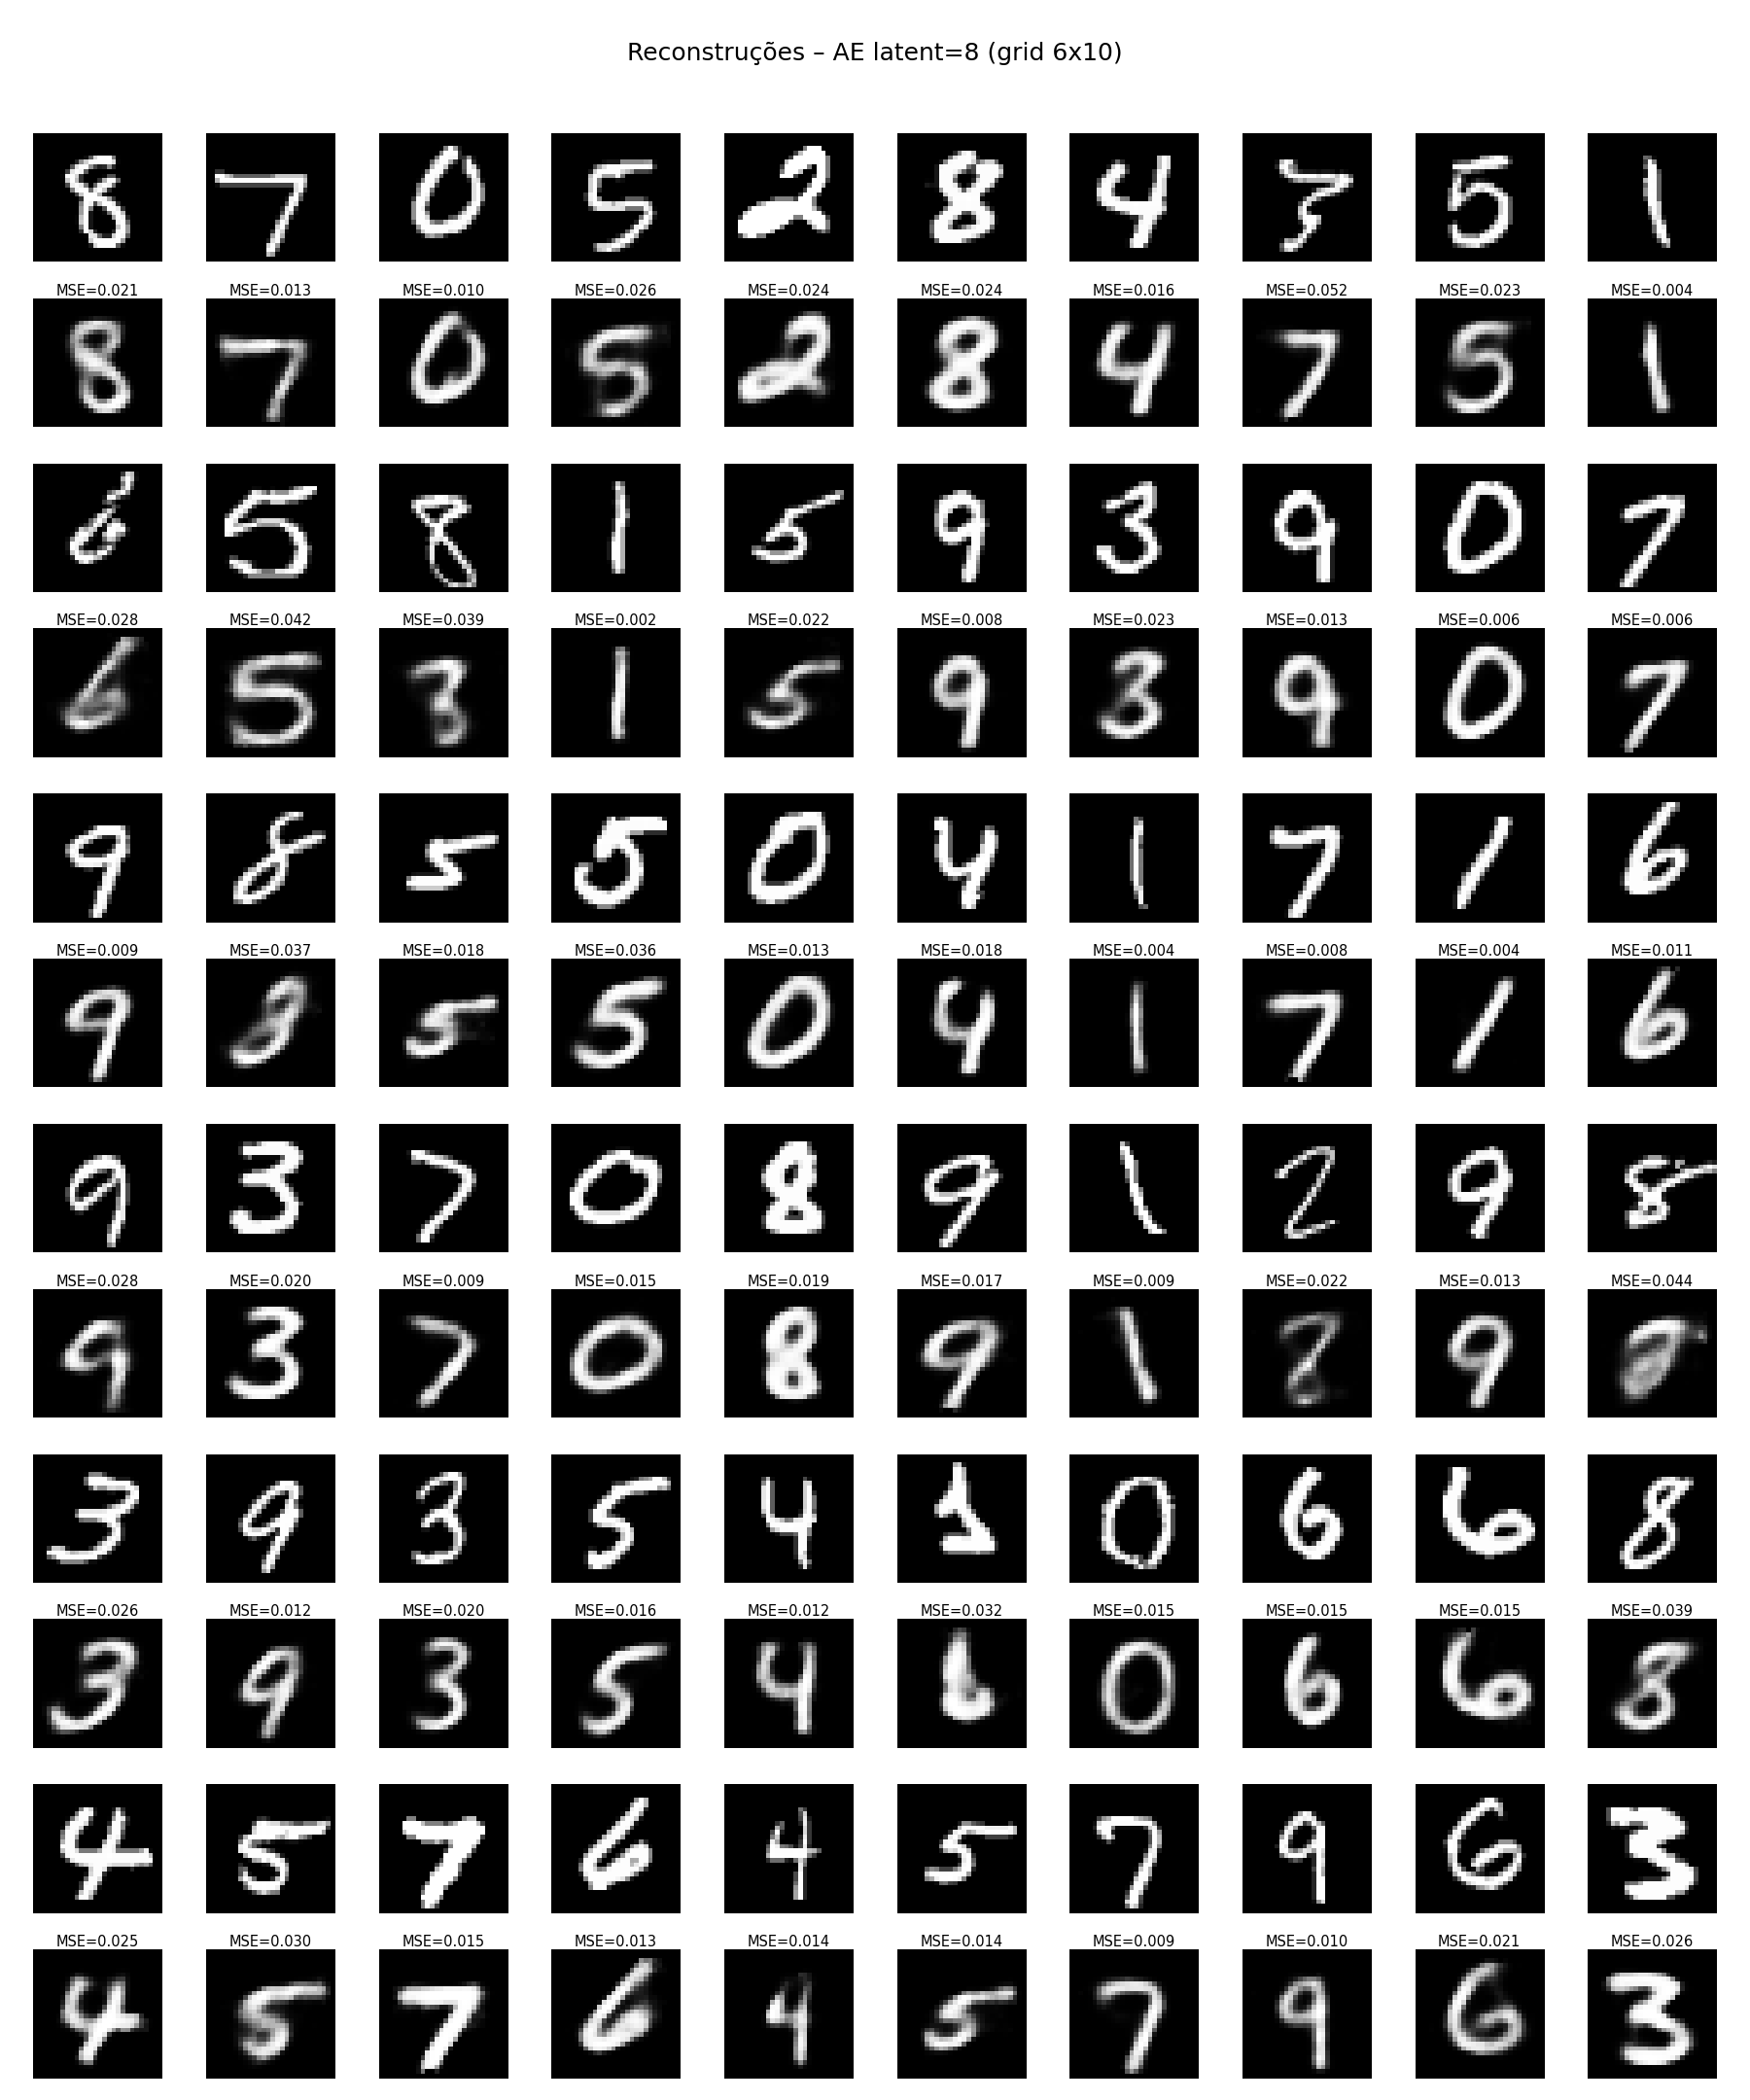

In [29]:
import numpy as np, matplotlib.pyplot as plt, os
from IPython.display import Image, display
from tensorflow import keras
from tensorflow.keras import layers

LATENT = 8
WEIGHTS_PATH = "autoencoder_latent8.weights.h5"
GRID = (6, 10)  # 6x10
SAVE_PATH = "recon_latent8_grid.png"

# --- Dados ---
(_, _), (x_test, _) = keras.datasets.mnist.load_data()
x_test = x_test.astype("float32")/255.0
x_test_flat = x_test.reshape((-1, 28*28))

# --- Modelo (idêntico ao 2A) ---
inp = keras.Input(shape=(784,))
x = layers.Dense(128, activation="relu")(inp)
x = layers.Dense(64, activation="relu")(x)
z = layers.Dense(LATENT, name="latent")(x)
x = layers.Dense(64, activation="relu")(z)
x = layers.Dense(128, activation="relu")(x)
out = layers.Dense(784, activation="sigmoid")(x)
autoenc = keras.Model(inp, out)

# Carregar pesos (falha silenciosa -> avisa)
try:
    autoenc.load_weights(WEIGHTS_PATH)
    print(f"[OK] Pesos carregados: {WEIGHTS_PATH}")
except Exception as e:
    print("[WARN] Não foi possível carregar pesos:", e)

# --- Seleção e reconstrução ---
n_rows, n_cols = GRID
n = n_rows * n_cols
rng = np.random.default_rng(42)
idx = rng.choice(x_test_flat.shape[0], n, replace=False)
X = x_test_flat[idx]
X_rec = autoenc.predict(X, verbose=0)
mse = np.mean((X - X_rec)**2, axis=1)

# --- Plot (original acima, reconstrução abaixo) ---
fig, axes = plt.subplots(n_rows*2, n_cols, figsize=(1.2*n_cols, 1.2*n_rows*2))
for j in range(n):
    r = j // n_cols
    c = j % n_cols
    axes[2*r, c].imshow(X[j].reshape(28,28), cmap="gray"); axes[2*r, c].axis("off")
    axes[2*r+1, c].imshow(X_rec[j].reshape(28,28), cmap="gray"); axes[2*r+1, c].axis("off")
    axes[2*r+1, c].set_title(f"MSE={mse[j]:.3f}", fontsize=7, pad=1)

plt.suptitle(f"Reconstruções – AE latent={LATENT} (grid {n_rows}x{n_cols})", fontsize=12)
plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig(SAVE_PATH, dpi=150)
print("[OK] Figura salva em:", os.path.abspath(SAVE_PATH))
plt.show()

# --- Mostra a imagem salva (funciona mesmo sem backend inline) ---
display(Image(filename=SAVE_PATH))


## Questão 2 C
Faça uma análise semelhante à feita acima, mas para o espaço latente de dimensão 2.

In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
LATENT=2
BATCH=512
EPOCHS=50
WEIGHTS_PATH = "autoencoder_latent2.weights.h5"

# Dados
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
x_train = (x_train.astype("float32")/255.).reshape((-1, 28*28))
x_test  = (x_test.astype("float32")/255.).reshape((-1, 28*28))

# Modelo
inp = keras.Input(shape=(784,))
x = layers.Dense(128, activation="relu")(inp)
x = layers.Dense(64, activation="relu")(x)
z = layers.Dense(LATENT, name="latent")(x)      # espaço 2D
x = layers.Dense(64, activation="relu")(z)
x = layers.Dense(128, activation="relu")(x)
out = layers.Dense(784, activation="sigmoid")(x)

autoenc = keras.Model(inp, out)
autoenc.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mse"])

cbs = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1)
]

hist = autoenc.fit(
    x_train, x_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH,
    shuffle=True,
    callbacks=cbs,
    verbose=2
)

test_loss, test_mse = autoenc.evaluate(x_test, x_test, verbose=0)
print(f"[RESULT] MSE médio (teste) latent=2: {test_mse:.6f}")

autoenc.save_weights(WEIGHTS_PATH)
print(f"[OK] Pesos salvos em: {WEIGHTS_PATH}")


Epoch 1/50
106/106 - 5s - 43ms/step - loss: 0.0892 - mse: 0.0892 - val_loss: 0.0680 - val_mse: 0.0680 - learning_rate: 1.0000e-03
Epoch 2/50
106/106 - 0s - 4ms/step - loss: 0.0618 - mse: 0.0618 - val_loss: 0.0573 - val_mse: 0.0573 - learning_rate: 1.0000e-03
Epoch 3/50
106/106 - 1s - 5ms/step - loss: 0.0557 - mse: 0.0557 - val_loss: 0.0534 - val_mse: 0.0534 - learning_rate: 1.0000e-03
Epoch 4/50
106/106 - 1s - 6ms/step - loss: 0.0526 - mse: 0.0526 - val_loss: 0.0512 - val_mse: 0.0512 - learning_rate: 1.0000e-03
Epoch 5/50
106/106 - 1s - 6ms/step - loss: 0.0506 - mse: 0.0506 - val_loss: 0.0488 - val_mse: 0.0488 - learning_rate: 1.0000e-03
Epoch 6/50
106/106 - 1s - 6ms/step - loss: 0.0483 - mse: 0.0483 - val_loss: 0.0464 - val_mse: 0.0464 - learning_rate: 1.0000e-03
Epoch 7/50
106/106 - 0s - 4ms/step - loss: 0.0465 - mse: 0.0465 - val_loss: 0.0449 - val_mse: 0.0449 - learning_rate: 1.0000e-03
Epoch 8/50
106/106 - 0s - 4ms/step - loss: 0.0454 - mse: 0.0454 - val_loss: 0.0441 - val_mse: 0.

[OK] Figura salva em: /content/recon_latent2_grid.png


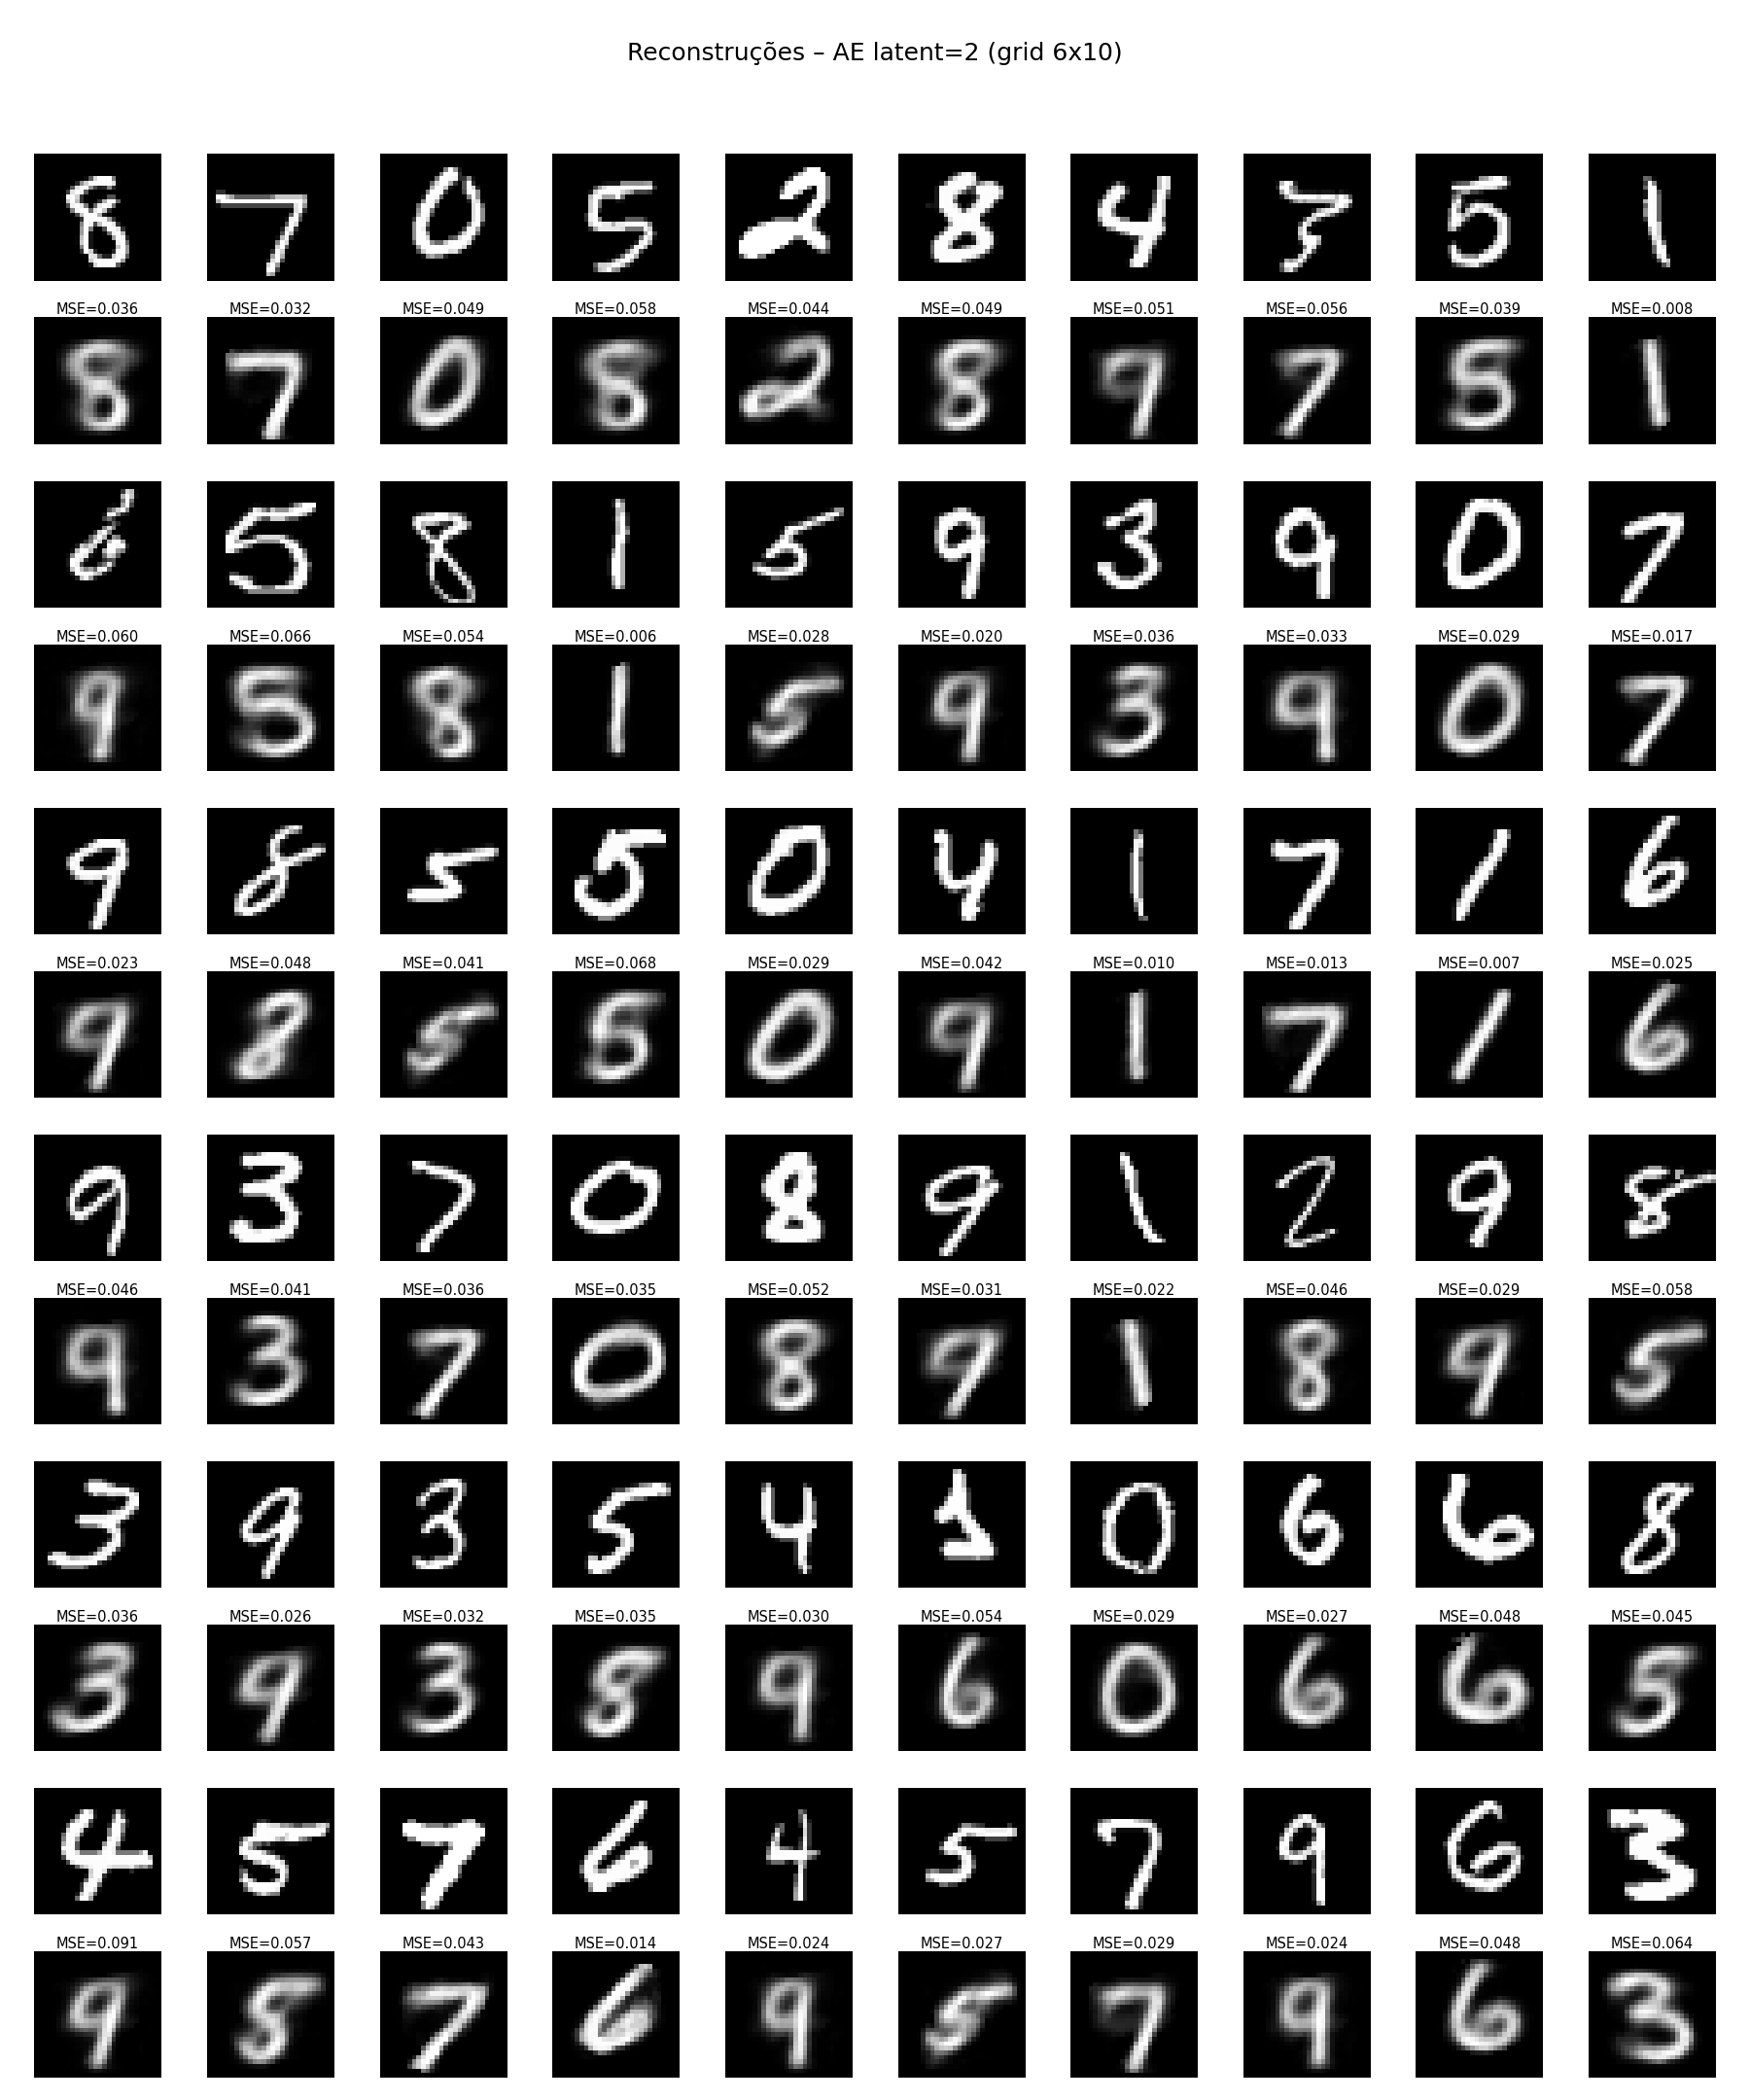

[RESULT] MSE médio (grid): 0.037595


In [31]:
import numpy as np, matplotlib.pyplot as plt, os
from IPython.display import Image, display
from tensorflow import keras
from tensorflow.keras import layers

LATENT=2
WEIGHTS_PATH="autoencoder_latent2.weights.h5"
GRID=(6,10)
SAVE_PATH="recon_latent2_grid.png"

# Dados
(_, _), (x_test, _) = keras.datasets.mnist.load_data()
x_test = (x_test.astype("float32")/255.).reshape((-1, 28*28))

# Modelo igual ao treino
inp = keras.Input(shape=(784,))
x = layers.Dense(128, activation="relu")(inp)
x = layers.Dense(64, activation="relu")(x)
z = layers.Dense(LATENT, name="latent")(x)
x = layers.Dense(64, activation="relu")(z)
x = layers.Dense(128, activation="relu")(x)
out = layers.Dense(784, activation="sigmoid")(x)
autoenc = keras.Model(inp, out)
autoenc.load_weights(WEIGHTS_PATH)

# Amostras e reconstrução
n_rows, n_cols = GRID
n = n_rows*n_cols
rng = np.random.default_rng(42)
idx = rng.choice(x_test.shape[0], n, replace=False)
X = x_test[idx]
X_rec = autoenc.predict(X, verbose=0)
mse = np.mean((X - X_rec)**2, axis=1)

# Plot
fig, axes = plt.subplots(n_rows*2, n_cols, figsize=(1.2*n_cols, 1.2*n_rows*2))
for j in range(n):
    r, c = j//n_cols, j % n_cols
    axes[2*r, c].imshow(X[j].reshape(28,28), cmap="gray"); axes[2*r, c].axis("off")
    axes[2*r+1, c].imshow(X_rec[j].reshape(28,28), cmap="gray"); axes[2*r+1, c].axis("off")
    axes[2*r+1, c].set_title(f"MSE={mse[j]:.3f}", fontsize=7, pad=1)

plt.suptitle(f"Reconstruções – AE latent=2 (grid {n_rows}x{n_cols})", fontsize=12)
plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig(SAVE_PATH, dpi=150)
print("[OK] Figura salva em:", os.path.abspath(SAVE_PATH))
plt.show()
display(Image(filename=SAVE_PATH))
print(f"[RESULT] MSE médio (grid): {mse.mean():.6f}")

In [32]:
import numpy as np, matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

LATENT=2
WEIGHTS_PATH="autoencoder_latent2.weights.h5"

# Dados com rótulos
(_, _), (x_test, y_test) = keras.datasets.mnist.load_data()
x_test = (x_test.astype("float32")/255.).reshape((-1, 28*28))

# Reconstruir encoder
inp = keras.Input(shape=(784,))
x = layers.Dense(128, activation="relu")(inp)
x = layers.Dense(64, activation="relu")(x)
z = layers.Dense(LATENT, name="latent")(x)
x_dec = layers.Dense(64, activation="relu")(z)
x_dec = layers.Dense(128, activation="relu")(x_dec)
out = layers.Dense(784, activation="sigmoid")(x_dec)
autoenc = keras.Model(inp, out)
autoenc.load_weights(WEIGHTS_PATH)

encoder = keras.Model(inp, z)
Z = encoder.predict(x_test, batch_size=2048, verbose=0)

plt.figure(figsize=(6,6))
scatter = plt.scatter(Z[:,0], Z[:,1], c=y_test, s=5, alpha=0.6)
plt.title("Espaço latente 2D — MNIST (cores = dígitos)")
plt.xlabel("z1"); plt.ylabel("z2")
plt.colorbar(scatter, ticks=range(10))
plt.tight_layout()
plt.show()


[OK] Pesos carregados: /content/autoencoder_latent2.weights.h5
[OK] Figura salva em: /content/latent2_map.png


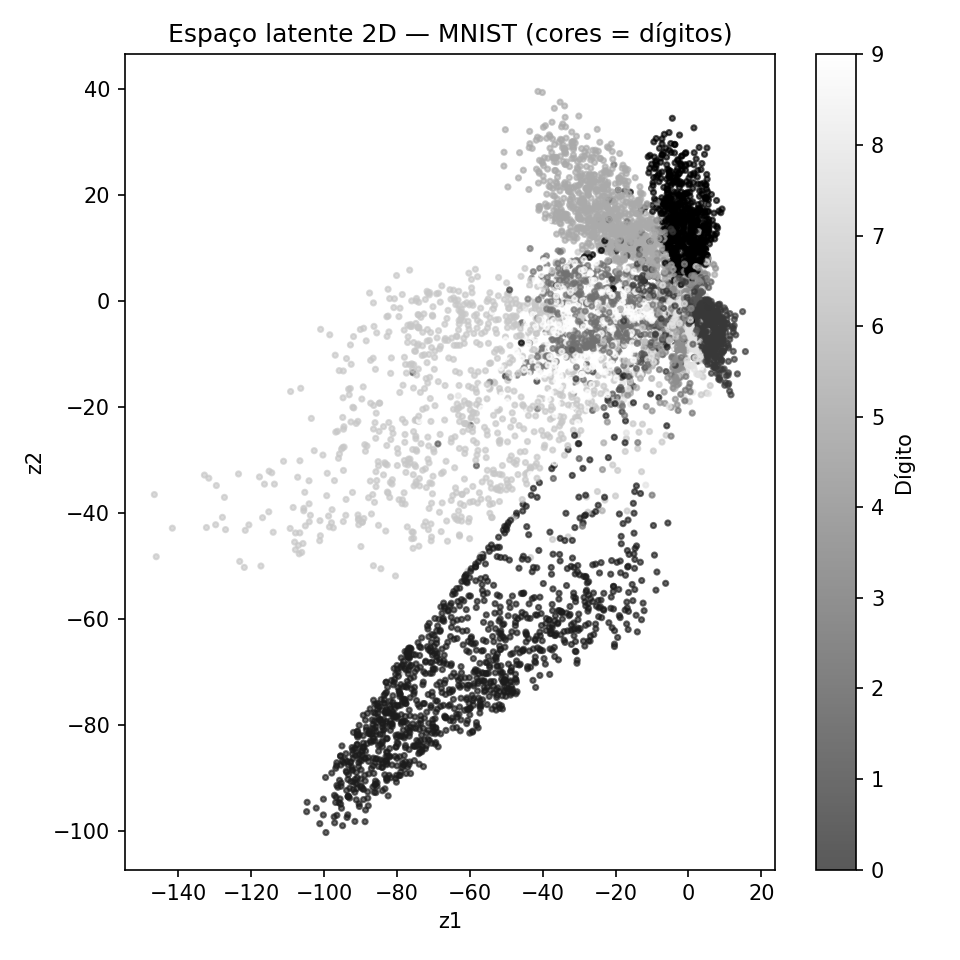

In [33]:
import os, numpy as np, matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image, display
from tensorflow import keras
from tensorflow.keras import layers

if not ("COLAB_GPU" in os.environ or "IPYKERNEL" in str(type(getattr(__import__('sys'), 'stdout', None)))):
    matplotlib.use("Agg")

LATENT = 2
WEIGHTS_PATH = "autoencoder_latent2.weights.h5"
SAVE_PATH = "latent2_map.png"

# --- Dados com rótulos ---
(_, _), (x_test, y_test) = keras.datasets.mnist.load_data()
x_test = (x_test.astype("float32")/255.).reshape((-1, 28*28))

# --- Reconstruir o mesmo modelo do treino e carregar pesos ---
inp = keras.Input(shape=(784,))
x = layers.Dense(128, activation="relu")(inp)
x = layers.Dense(64, activation="relu")(x)
z = layers.Dense(LATENT, name="latent")(x)
x_dec = layers.Dense(64, activation="relu")(z)
x_dec = layers.Dense(128, activation="relu")(x_dec)
out = layers.Dense(784, activation="sigmoid")(x_dec)
autoenc = keras.Model(inp, out)

try:
    autoenc.load_weights(WEIGHTS_PATH)
    print(f"[OK] Pesos carregados: {os.path.abspath(WEIGHTS_PATH)}")
except Exception as e:
    print("[WARN] Falha ao carregar pesos:", e, "\n[INFO] O mapa refletirá pesos não treinados.")

# --- Encoder isolado e projeção ---
encoder = keras.Model(inp, z)
Z = encoder.predict(x_test, batch_size=4096, verbose=0)  # rápido e estável

# --- Plot e salvar ---
plt.figure(figsize=(6.4, 6.4), dpi=120)
sc = plt.scatter(Z[:,0], Z[:,1], c=y_test, s=6, alpha=0.65)
plt.title("Espaço latente 2D — MNIST (cores = dígitos)")
plt.xlabel("z1"); plt.ylabel("z2")
cbar = plt.colorbar(sc, ticks=range(10))
cbar.ax.set_ylabel("Dígito")
plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=150)
print(f"[OK] Figura salva em: {os.path.abspath(SAVE_PATH)}")

# --- Exibir de forma robusta ---
plt.show()                 # deve bastar no Colab
display(Image(SAVE_PATH))  # garante exibição mesmo se o backend inline falhar


#### **2. Visualizando o Espaço Latente**

Usando o modelo com dimensionalidade 2, podemos visualizar diretamente o espaço latente em um gráfico 2D.

  * Use o modelo `encoder_dim2` que você criou para prever as representações latentes do conjunto de teste (`x_test`).
  * A cor da cada ponto neste gráfico vem do seu rótulo verdadeiro, dado em `y_test`

<!-- end list -->

In [35]:
# Vamos criar um modelo apenas com a parte do encoder do último autoencoder e gerar os valores do espaço latente
encoder_2 = keras.Model(inp, z)
encoded_imgs_2D = encoder_2.predict(x_test)


plt.figure(figsize=(12, 10))
scatter = plt.scatter(encoded_imgs_2D[:, 0], encoded_imgs_2D[:, 1], c=y_test, cmap='tab10', s=8, alpha=0.7)
plt.xscale('log') # Escala log-log facilita a visualização nesse caso. Todos os valores são positivos, já que acabaram de passar por uma ativação ReLU
plt.yscale('log')
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label('Rótulo do Dígito')
plt.xlabel("Dimensão Latente 1")
plt.ylabel("Dimensão Latente 2")
plt.title("Visualização do Espaço Latente 2D do MNIST (Escala Log-Log)")
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


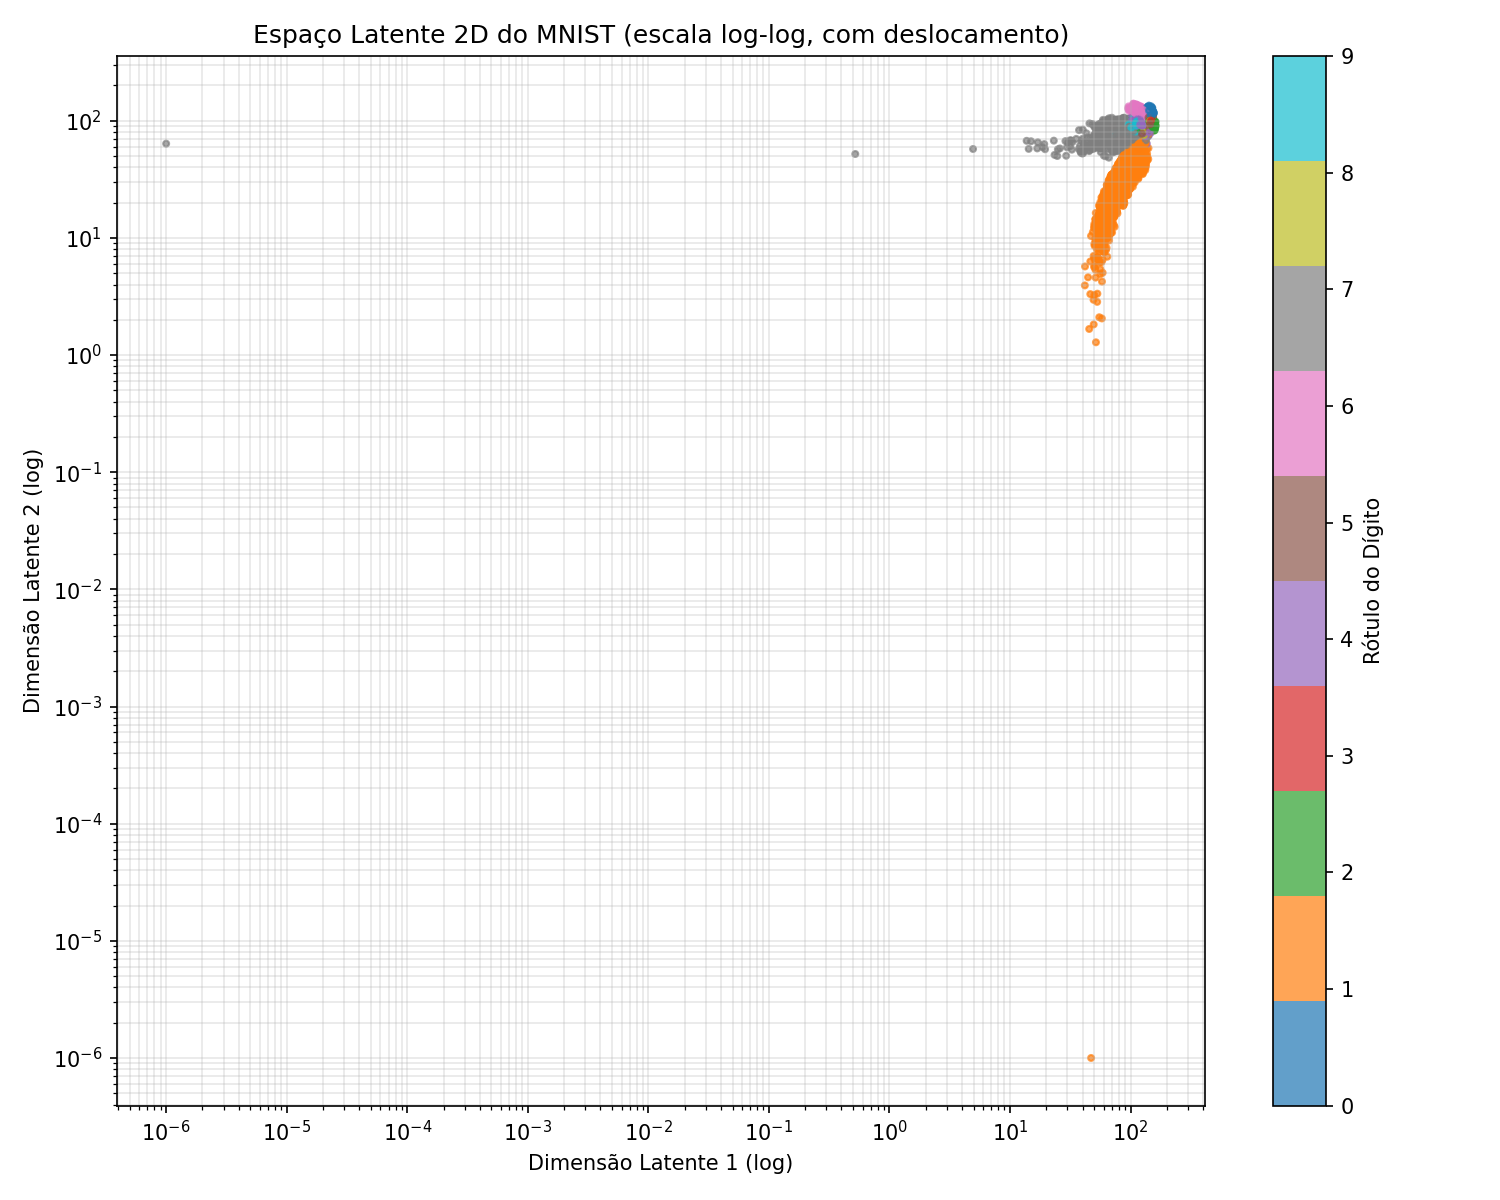

In [36]:
# %% Plot latente 2D (log-log com deslocamento para > 0)
import numpy as np, matplotlib.pyplot as plt
from IPython.display import Image, display

encoded = encoded_imgs_2D.copy()  # use o já calculado

# Desloca cada eixo para que todos valores fiquem > 0
eps = 1e-6
for k in [0, 1]:
    min_k = np.min(encoded[:, k])
    if min_k <= 0:
        encoded[:, k] = encoded[:, k] - min_k + eps

save_path = "latent2_map_loglog.png"
plt.figure(figsize=(10, 8))
scatter = plt.scatter(encoded[:, 0], encoded[:, 1], c=y_test, cmap='tab10', s=8, alpha=0.7)
plt.xscale('log'); plt.yscale('log')
cbar = plt.colorbar(scatter, ticks=range(10)); cbar.set_label('Rótulo do Dígito')
plt.xlabel("Dimensão Latente 1 (log)")
plt.ylabel("Dimensão Latente 2 (log)")
plt.title("Espaço Latente 2D do MNIST (escala log-log, com deslocamento)")
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(save_path, dpi=150)
plt.show()
display(Image(save_path))


## Questão 3

Faça uma análise da imagem gerada acima.
- O que significa quando os pontos de uma mesma cor estão na mesma região do gráfico?
Indica que o encoder aprendeu uma representação coesa para aquele dígito (baixa variação intra-classe no z2D). Em geral, isso se reflete em MSE menor e maior separabilidade se usarmos o latente como feature.

- Algumas regiões acabaram sendo ocupadas por pontos de duas cores diferentes. Como isso se relaciona à resposta da questão 2 C em relação aos dígitos que foram mais confundidos entre si?
Mostra manifolds sobrepostos por falta de capacidade do z=2 para separar padrões parecidos. Conecta com a Q2-C: justamente esses dígitos tendem a apresentar erros maiores (p95↑) e mais confusão (ex.: 3–5–8, 7–9, 0–6–9).

## Questão 4 A

Para gerar novos dígitos a partir deste modelo, podemos usar apenas o decoder.
Quais valores escolheríamos para o espaço latente caso queiramos um novo dígito 0?
Podemos pegar o centro (média) do cluster dos zeros no espaço latente e amostrar algo próximo dele. No AE, pontos no latente perto do cluster “0” decodificam para imagens que parecem “0”.

Observação importante: Apesar de autoencoders serem uma opção para a geração de novos dados, como estamos fazendo aqui, existem técnicas diferentes, que são mais adequadas para essa tarefa. Entre elas, há o Variational Autoencoder, que usa autoencoders como base

In [ ]:
# Questão 4 B: Crie o decoder do autoencoder de dimensão latente 2 e gere um novo dígito 0

x1 =
x2 =

latent = np.array([[x1, x2]])

decoder_2 =
generated_img =

plt.imshow(generated_img.reshape(28, 28))

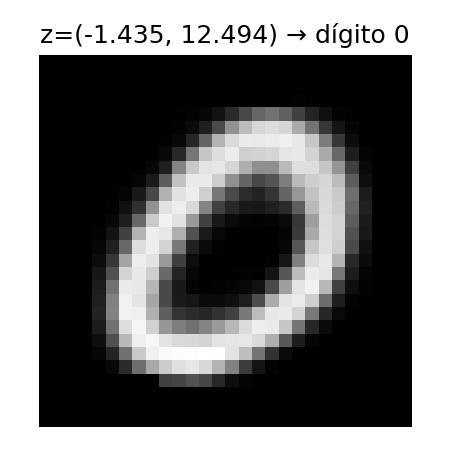

[OK] Figura salva em: /content/digit0_generated.png


In [38]:
# %% Q4B — Decoder (latent=2) e geração de um novo "0" — exibição garantida no Colab
import os, numpy as np, matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image, display
from tensorflow import keras
from tensorflow.keras import layers

# (Se rodar fora do Colab/Jupyter, força backend sem GUI)
if "COLAB_GPU" not in os.environ:
    matplotlib.use("Agg")

LATENT = 2
WEIGHTS_PATH = "autoencoder_latent2.weights.h5"
SAVE_PATH = "digit0_generated.png"

# --- Reconstrói AE (mesma arquitetura do treino) e carrega pesos ---
inp = keras.Input(shape=(784,))
h1 = layers.Dense(128, activation="relu")(inp)
h2 = layers.Dense(64, activation="relu")(h1)
z  = layers.Dense(LATENT, name="latent")(h2)
d1 = layers.Dense(64, activation="relu")(z)
d2 = layers.Dense(128, activation="relu")(d1)
out = layers.Dense(784, activation="sigmoid")(d2)
autoenc = keras.Model(inp, out)
autoenc.load_weights(WEIGHTS_PATH)

# --- Encoder para achar o centróide dos zeros ---
(_, _), (x_test, y_test) = keras.datasets.mnist.load_data()
x_test = (x_test.astype("float32")/255.).reshape((-1, 28*28))
encoder_2 = keras.Model(inp, z)
Z0 = encoder_2.predict(x_test[y_test==0], batch_size=4096, verbose=0)
mu0 = Z0.mean(axis=0)

# === Escolha dos valores latentes ===
x1 = float(mu0[0])
x2 = float(mu0[1])
latent = np.array([[x1, x2]])

# --- Decoder isolado (reutiliza camadas do AE já carregado) ---
z_in = keras.Input(shape=(LATENT,))
x = autoenc.get_layer(index=4)(z_in)   # Dense(64) do decoder
x = autoenc.get_layer(index=5)(x)      # Dense(128)
x = autoenc.get_layer(index=6)(x)      # Dense(784) sigmoid (saída)
decoder_2 = keras.Model(z_in, x)

# --- Geração e plot ---
generated_img = decoder_2.predict(latent, verbose=0)[0].reshape(28, 28)

plt.figure(figsize=(3,3), dpi=150)
plt.imshow(generated_img, cmap="gray")
plt.title(f"z=({x1:.3f}, {x2:.3f}) → dígito 0")
plt.axis("off")
plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=150)
plt.show()                 # exibe inline no Colab
display(Image(SAVE_PATH))  # garante exibição mesmo se o backend falhar
print("[OK] Figura salva em:", os.path.abspath(SAVE_PATH))


## Parte III: Autoencoder para detecção de anomalias

Autoencoders são uma ótima forma de detectarmos anomalias em dados.
Nesta parte do trabalho, vamos criar um autoencoder com base em uma base de dados falha, que não possui o número 4.
Ou seja, se tentarmos usar o autoencoder com o número 4, ele tentará reproduzir algo que nunca viu. Isso se assemelha a casos reais de detecção de anomalias. Nesse cenário, o número 5 pode ser pensado como uma anomalia.

In [39]:
# Questão 5 A: Gere novas bases de dados removendo o número 4
from tensorflow import keras
import numpy as np

# Carrega dados
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Máscaras (mantém tudo que NÃO é 4)
mask_train = y_train != 4
mask_test  = y_test  != 4

# Bases sem o dígito 4 (normalizadas em [0,1])
x_train_no_4 = x_train[mask_train].astype("float32") / 255.0
y_train_no_4 = y_train[mask_train]

x_test_no_4  = x_test[mask_test].astype("float32") / 255.0
y_test_no_4  = y_test[mask_test]

# (Opcional) versão achatada para AE totalmente conectado:
# x_train_no_4 = x_train_no_4.reshape((-1, 28*28))
# x_test_no_4  = x_test_no_4.reshape((-1, 28*28))

print(x_train_no_4.shape, y_train_no_4.shape)
print(x_test_no_4.shape, y_test_no_4.shape)


(54158, 28, 28) (54158,)
(9018, 28, 28) (9018,)


In [40]:
# Questão 5 B: Crie um novo autoencoder de dimensão latente 16 e o treine com esta nova base de dados
# %% Q5B — Autoencoder latent=16 treinado sem o dígito 4 (MNIST)
import numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
LATENT=16
BATCH=512
EPOCHS=50
WEIGHTS_PATH = "autoencoder_latent16_no4.weights.h5"

# --- Dados (usa a base da 5A se existir; senão recria) ---
try:
    x_train_no_4, y_train_no_4
    x_test_no_4,  y_test_no_4
except NameError:
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
    mask_train = y_train != 4
    mask_test  = y_test  != 4
    x_train_no_4 = x_train[mask_train].astype("float32")/255.0
    y_train_no_4 = y_train[mask_train]
    x_test_no_4  = x_test[mask_test].astype("float32")/255.0
    y_test_no_4  = y_test[mask_test]

# Flatten para AE denso
x_train_no_4_flat = x_train_no_4.reshape((-1, 28*28))
x_test_no_4_flat  = x_test_no_4.reshape((-1, 28*28))

print(f"[INFO] Train sem '4': {x_train_no_4_flat.shape} | Test sem '4': {x_test_no_4_flat.shape}")

# --- Modelo (784 -> 256 -> 128 -> z16 -> 128 -> 256 -> 784) ---
inp = keras.Input(shape=(784,))
x = layers.Dense(256, activation="relu")(inp)
x = layers.Dense(128, activation="relu")(x)
z = layers.Dense(LATENT, name="latent")(x)
x = layers.Dense(128, activation="relu")(z)
x = layers.Dense(256, activation="relu")(x)
out = layers.Dense(784, activation="sigmoid")(x)

autoenc = keras.Model(inp, out, name="AE_latent16_no4")
autoenc.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mse"])
autoenc.summary()

# --- Callbacks ---
cbs = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1)
]

# --- Treino ---
hist = autoenc.fit(
    x_train_no_4_flat, x_train_no_4_flat,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH,
    shuffle=True,
    callbacks=cbs,
    verbose=2
)

# --- Avaliação (teste sem 4) ---
test_loss, test_mse = autoenc.evaluate(x_test_no_4_flat, x_test_no_4_flat, verbose=0)
print(f"[RESULT] MSE médio (teste, sem '4'): {test_mse:.6f}")

# --- Salvar pesos ---
autoenc.save_weights(WEIGHTS_PATH)
print(f"[OK] Pesos salvos em: {WEIGHTS_PATH}")

# (Opcional) criar encoder/decoder isolados para uso posterior
encoder16_no4 = keras.Model(inp, z, name="encoder16_no4")

z_in = keras.Input(shape=(LATENT,))
d = autoenc.layers[-3](z_in)   # Dense(128)
d = autoenc.layers[-2](d)      # Dense(256)
d_out = autoenc.layers[-1](d)  # Dense(784, sigmoid)
decoder16_no4 = keras.Model(z_in, d_out, name="decoder16_no4")


[INFO] Train sem '4': (54158, 784) | Test sem '4': (9018, 784)


Model: "AE_latent16_no4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 472,608 (1.80 MB)

 Trainable params: 472,608 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
96/96 - 6s - 58ms/step - loss: 0.0825 - mse: 0.0825 - val_loss: 0.0549 - val_mse: 0.0549 - learning_rate: 1.0000e-03
Epoch 2/50
96/96 - 0s - 4ms/step - loss: 0.0434 - mse: 0.0434 - val_loss: 0.0350 - val_mse: 0.0350 - learning_rate: 1.0000e-03
Epoch 3/50
96/96 - 0s - 4ms/step - loss: 0.0301 - mse: 0.0301 - val_loss: 0.0262 - val_mse: 0.0262 - learning_rate: 1.0000e-03
Epoch 4/50
96/96 - 0s - 4ms/step - loss: 0.0239 - mse: 0.0239 - val_loss: 0.0221 - val_mse: 0.0221 - learning_rate: 1.0000e-03
Epoch 5/50
96/96 - 0s - 4ms/step - loss: 0.0208 - mse: 0.0208 - val_loss: 0.0199 - val_mse: 0.0199 - learning_rate: 1.0000e-03
Epoch 6/50
96/96 - 0s - 4ms/step - loss: 0.0191 - mse: 0.0191 - val_loss: 0.0186 - val_mse: 0.0186 - learning_rate: 1.0000e-03
Epoch 7/50
96/96 - 1s - 7ms/step - loss: 0.0178 - mse: 0.0178 - val_loss: 0.0175 - val_mse: 0.0175 - learning_rate: 1.0000e-03
Epoch 8/50
96/96 - 0s - 4ms/step - loss: 0.0169 - mse: 0.0169 - val_loss: 0.0166 - val_mse: 0.0166 - learning_

[OK] Pesos carregados: /content/autoencoder_latent16_no4.weights.h5
[OK] Figura salva em: /content/figs_q5c/recon_latent16_no4_grid.png


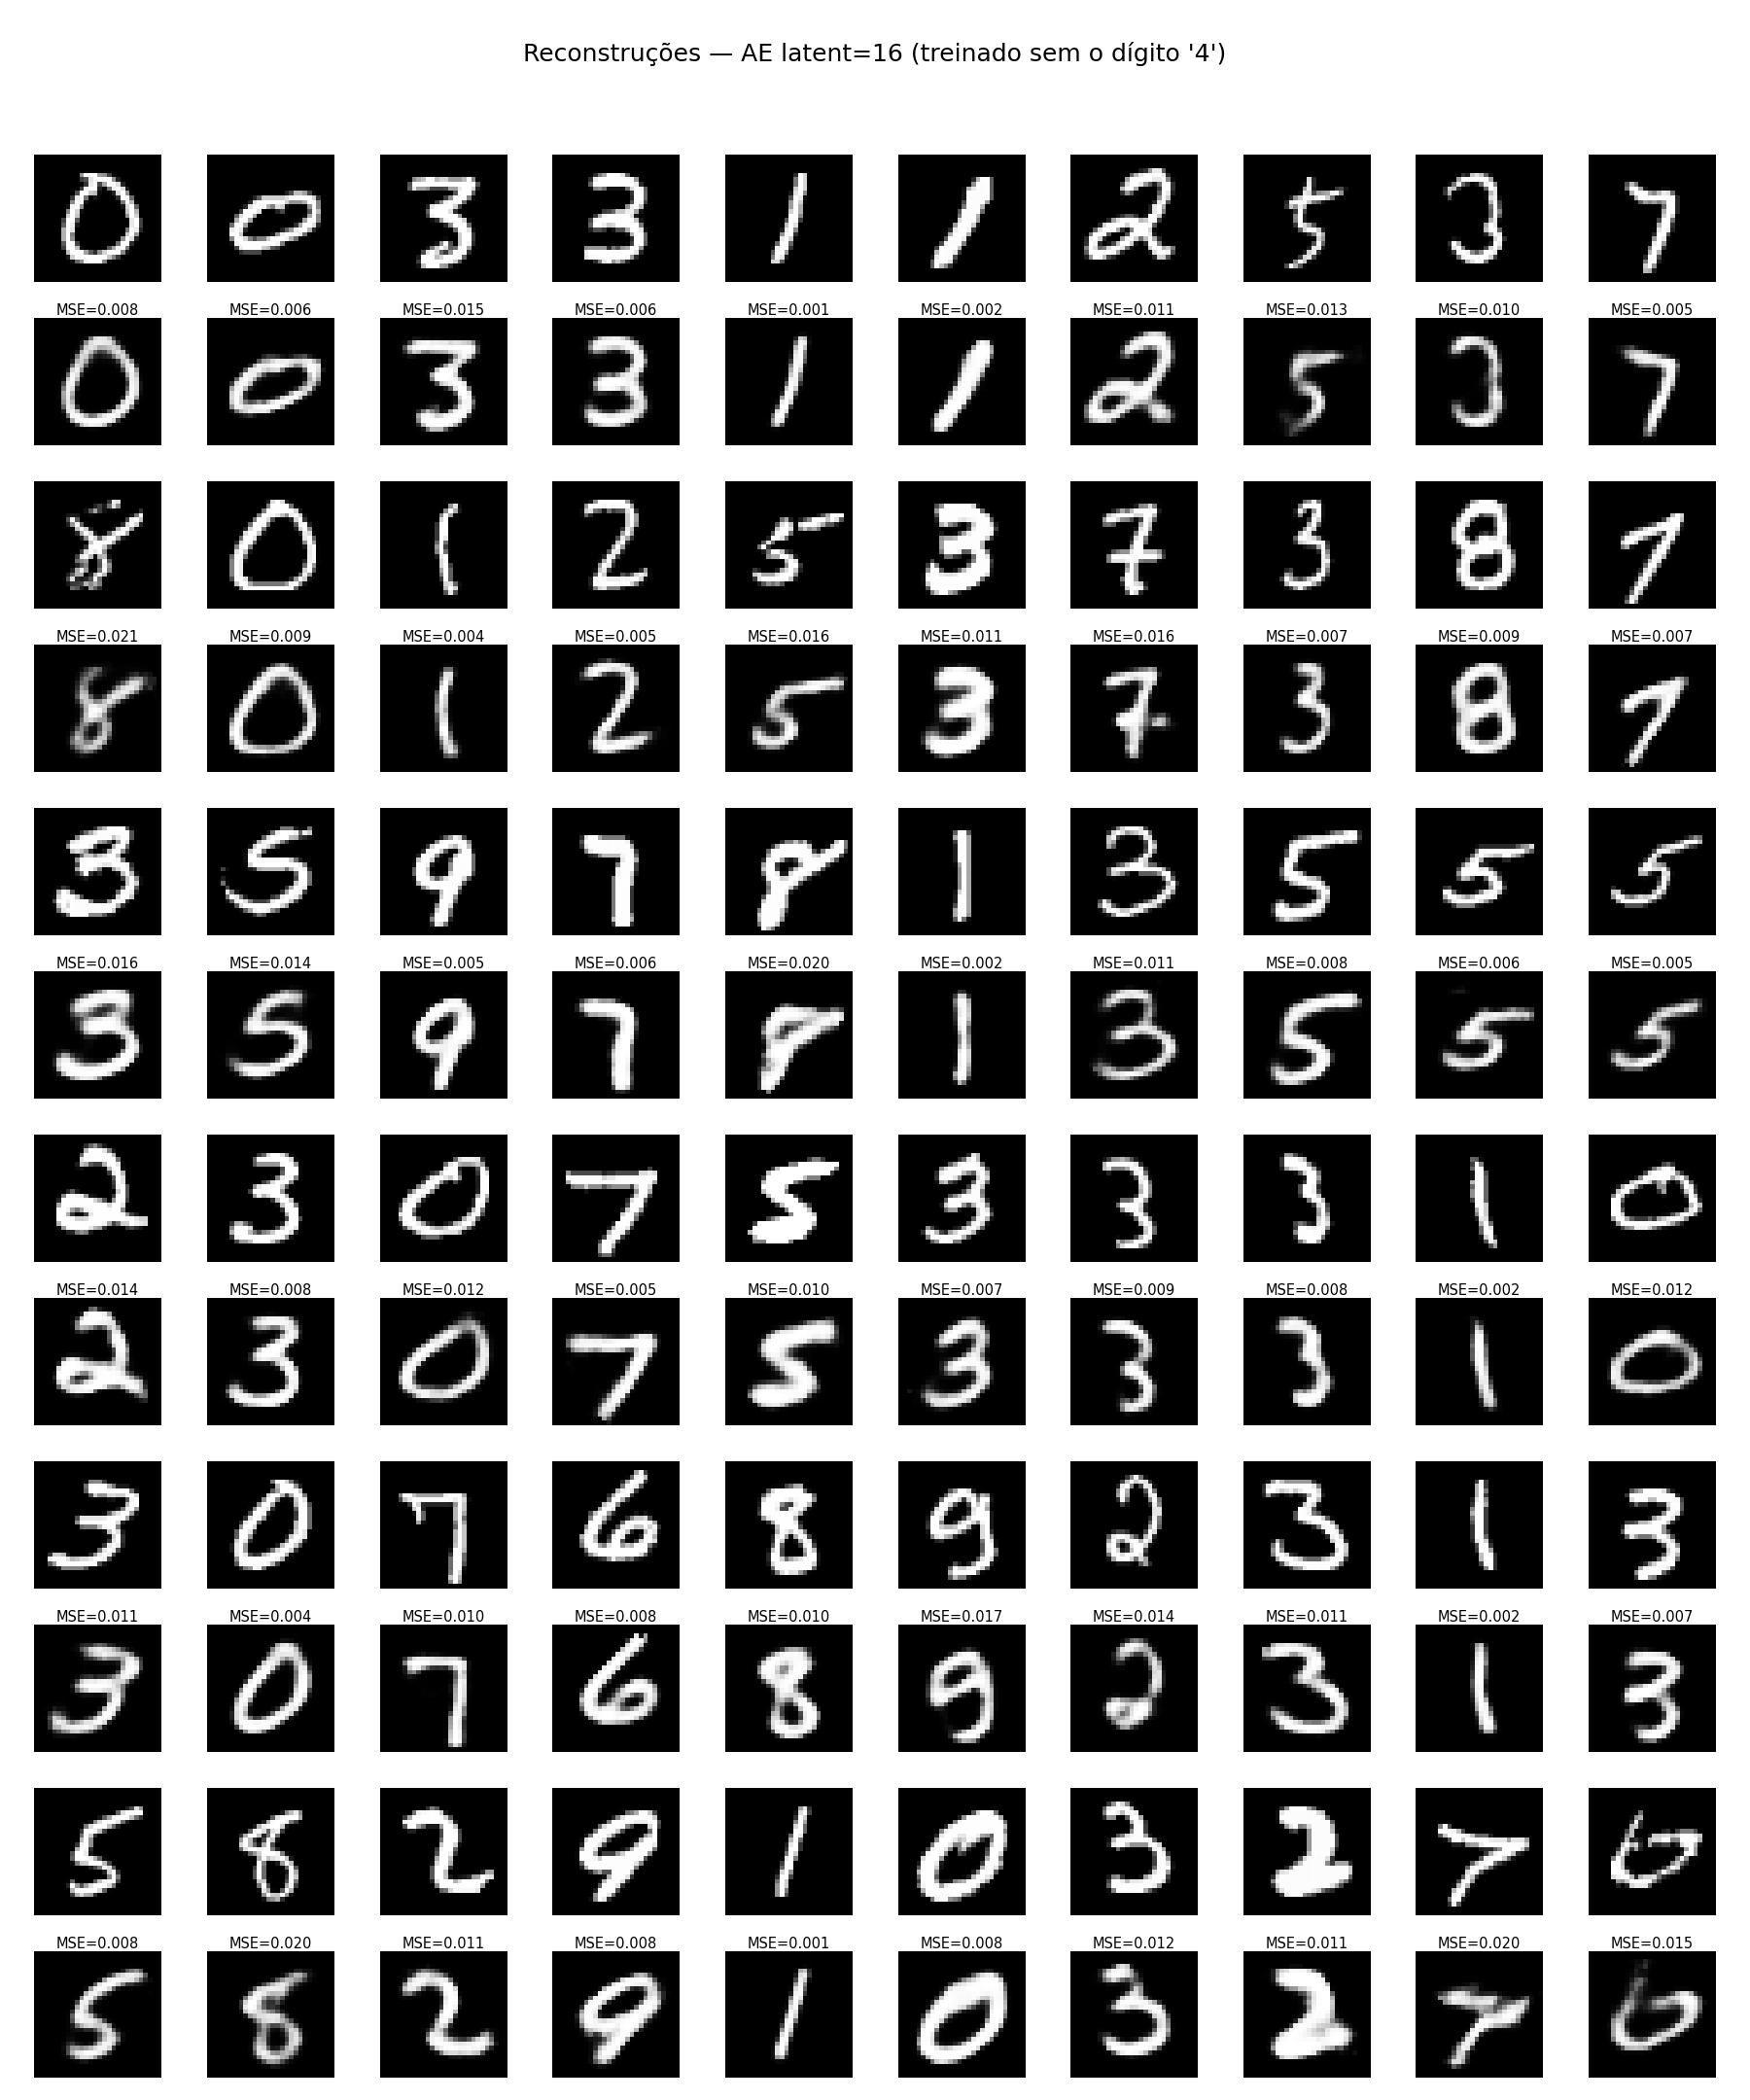

[RESULT] MSE médio (grid): 0.009539


In [42]:
# Questão 5 C: Plote exemplos da base de dados de teste reconstruidos com o novo autoencoder
# %% Q5C — Reconstruções (teste sem '4') com AE latent=16 — exibição garantida
import os, numpy as np, matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image, display
from tensorflow import keras
from tensorflow.keras import layers

# Backend robusto se rodar fora do notebook
if "COLAB_GPU" not in os.environ:
    matplotlib.use("Agg")

LATENT = 16
WEIGHTS_PATH = "autoencoder_latent16_no4.weights.h5"
GRID = (6, 10)  # 6 linhas x 10 colunas (pares: original acima, reconstrução abaixo)
SAVE_DIR = "figs_q5c"; os.makedirs(SAVE_DIR, exist_ok=True)
SAVE_PATH = os.path.join(SAVE_DIR, "recon_latent16_no4_grid.png")

# --- Dados (usa variáveis da 5A se existirem; senão recria) ---
try:
    x_test_no_4
    y_test_no_4
except NameError:
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
    mask_test  = y_test != 4
    x_test_no_4  = x_test[mask_test].astype("float32")/255.0
    y_test_no_4  = y_test[mask_test]

x_test_flat = x_test_no_4.reshape((-1, 28*28))

# --- Modelo (mesma arquitetura da 5B) ---
inp = keras.Input(shape=(784,))
x = layers.Dense(256, activation="relu")(inp)
x = layers.Dense(128, activation="relu")(x)
z = layers.Dense(LATENT, name="latent")(x)
x = layers.Dense(128, activation="relu")(z)
x = layers.Dense(256, activation="relu")(x)
out = layers.Dense(784, activation="sigmoid")(x)
autoenc = keras.Model(inp, out, name="AE_latent16_no4")

# Carregar pesos
if os.path.exists(WEIGHTS_PATH):
    autoenc.load_weights(WEIGHTS_PATH)
    print(f"[OK] Pesos carregados: {os.path.abspath(WEIGHTS_PATH)}")
else:
    print(f"[WARN] Pesos não encontrados: {WEIGHTS_PATH} — o gráfico refletirá pesos não treinados.")

# --- Seleção de amostras e reconstrução ---
n_rows, n_cols = GRID
n = n_rows * n_cols
rng = np.random.default_rng(42)
idx = rng.choice(x_test_flat.shape[0], n, replace=False)
X = x_test_flat[idx]
X_rec = autoenc.predict(X, verbose=0)
mse = np.mean((X - X_rec)**2, axis=1)

# --- Plot (original em cima, reconstrução embaixo) ---
fig, axes = plt.subplots(n_rows*2, n_cols, figsize=(1.2*n_cols, 1.2*n_rows*2))
for j in range(n):
    r, c = j // n_cols, j % n_cols
    axes[2*r, c].imshow(X[j].reshape(28,28), cmap="gray");     axes[2*r, c].axis("off")
    axes[2*r+1, c].imshow(X_rec[j].reshape(28,28), cmap="gray"); axes[2*r+1, c].axis("off")
    axes[2*r+1, c].set_title(f"MSE={mse[j]:.3f}", fontsize=7, pad=1)

plt.suptitle(f"Reconstruções — AE latent=16 (treinado sem o dígito '4')", fontsize=12)
plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig(SAVE_PATH, dpi=150)
print("[OK] Figura salva em:", os.path.abspath(SAVE_PATH))
plt.show()
display(Image(SAVE_PATH))

# (Opcional) MSE médio do grid
print(f"[RESULT] MSE médio (grid): {mse.mean():.6f}")


[OK] Pesos carregados: /content/autoencoder_latent16_no4.weights.h5


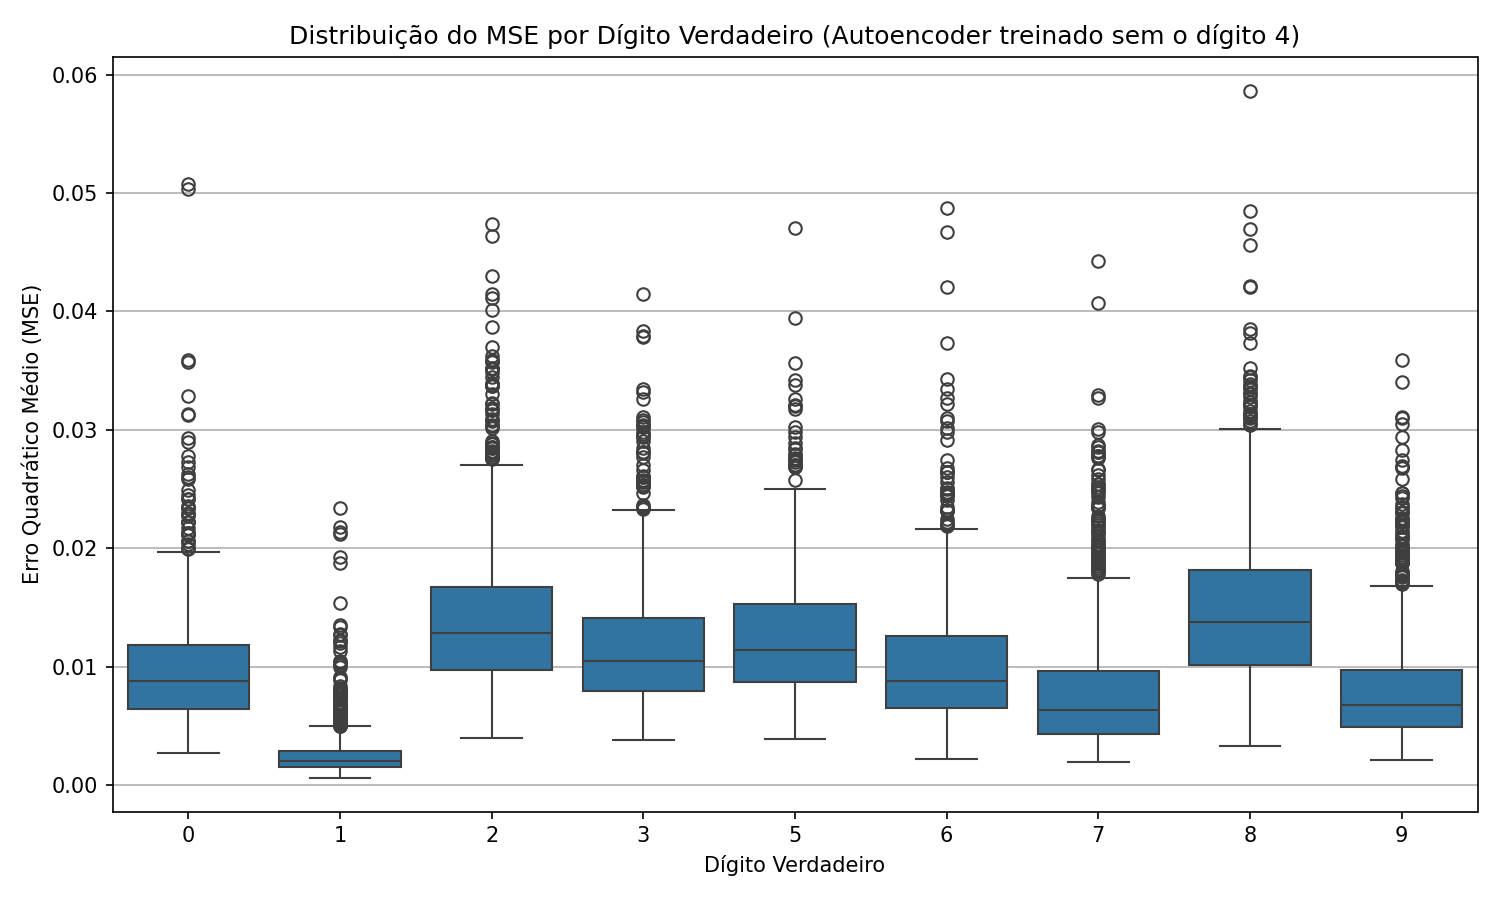

           mean    median  quantile
label                              
0      0.009921  0.008768  0.008768
1      0.002585  0.002002  0.002002
2      0.014092  0.012804  0.012804
3      0.011687  0.010477  0.010477
5      0.012583  0.011430  0.011430
6      0.010317  0.008814  0.008814
7      0.008037  0.006318  0.006318
8      0.015090  0.013726  0.013726
9      0.008171  0.006709  0.006709


In [44]:
# Vamos plotar o error médio da rede ao tentar reconstruir cada dígito

import os, numpy as np, matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import Image, display
from tensorflow import keras
from tensorflow.keras import layers

# Backend robusto fora do Colab/Jupyter
if "COLAB_GPU" not in os.environ:
    matplotlib.use("Agg")

LATENT = 16
WEIGHTS_PATH = "autoencoder_latent16_no4.weights.h5"
SAVE_DIR = "figs_q5c"; os.makedirs(SAVE_DIR, exist_ok=True)
SAVE_FIG = os.path.join(SAVE_DIR, "boxplot_mse_por_digito_no4.png")

# --- Dados (reusa variáveis da 5A se existirem; senão recria) ---
try:
    x_test_no_4, y_test_no_4
except NameError:
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
    mask_test = y_test != 4
    x_test_no_4 = x_test[mask_test].astype("float32")/255.0
    y_test_no_4 = y_test[mask_test]

x_test_flat = x_test_no_4.reshape((-1, 28*28))

# --- Modelo (igual ao usado na 5B) ---
inp = keras.Input(shape=(784,))
x = layers.Dense(256, activation="relu")(inp)
x = layers.Dense(128, activation="relu")(x)
z = layers.Dense(LATENT, name="latent")(x)
x = layers.Dense(128, activation="relu")(z)
x = layers.Dense(256, activation="relu")(x)
out = layers.Dense(784, activation="sigmoid")(x)
autoenc = keras.Model(inp, out, name="AE_latent16_no4")

if os.path.exists(WEIGHTS_PATH):
    autoenc.load_weights(WEIGHTS_PATH)
    print(f"[OK] Pesos carregados: {os.path.abspath(WEIGHTS_PATH)}")
else:
    print(f"[WARN] Pesos não encontrados: {WEIGHTS_PATH} — o gráfico refletirá pesos não treinados.")

# --- MSE por amostra ---
X_rec = autoenc.predict(x_test_flat, batch_size=2048, verbose=0)
mse_per_sample = np.mean((x_test_flat - X_rec)**2, axis=1)

# --- DataFrame para o seaborn ---
mse_df = pd.DataFrame({
    "label": y_test_no_4.astype(int),
    "mse": mse_per_sample.astype(float)
})

# --- Plot: boxplot por dígito ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='mse', data=mse_df)  # formato solicitado
plt.xlabel("Dígito Verdadeiro")
plt.ylabel("Erro Quadrático Médio (MSE)")
plt.title("Distribuição do MSE por Dígito Verdadeiro (Autoencoder treinado sem o dígito 4)")
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(SAVE_FIG, dpi=150)
plt.show()
display(Image(SAVE_FIG))

# (Opcional) Métricas rápidas por dígito
print(mse_df.groupby("label")["mse"].agg(["mean","median","quantile"]).round(6).to_string())


## Questão 5 D

- Por que o novo autoencoder teve um maior erro no dígito 4?
O AE não viu “4” no treino; logo, seu espaço latente não codifica bem suas variações. Ao tentar reconstruí-lo, “força” o dígito a parecer com padrões conhecidos (0, 9, etc.), gerando maior MSE.

- Como isso pode ser usado para detecção de anomalias?
Calibre um limiar (ex.: P95 do MSE no treino sem “4”). No teste, amostras com MSE acima do limiar são marcadas como anomalia. Assim, “4” (fora de distribuição) tende a disparar.

- No caso de um auto encoder com um espaço latente maior, essa detecção de anomalias pode se tornar mais difícil. O que explica isso?
Com maior capacidade, o decoder consegue generalizar/reconstruir até padrões não vistos, reduzindo o gap de erro entre normal e anômalo. Resultado: separação pior (AUC↓).Mitigações: regularização (L1/L2, sparsity), bottleneck mais estreito, VAE/contrastive, data augmentation e limiar adaptativo por classe/subgrupo.

Por que o erro no “4” ficou maior?
O modelo nunca “aprendeu” o 4 (foi tirado do treino). Quando vê um 4, tenta reconstruir como se fosse algo que conhece (0, 9…), e erra mais.

Como usar isso para detectar anomalias?
Medimos o erro de reconstrução. Se o erro passar de um limite (calculado nos dados “normais”), marcamos como anomalia. Como o 4 não foi treinado, ele tende a ultrapassar esse limite.

Por que um espaço latente maior atrapalha?
Com mais “memória” interna, o modelo consegue copiar melhor até o que não conhece, deixando o erro do estranho mais parecido com o normal. Aí fica mais difícil separar o que é anomalia.